# 🎬 Hollywood Movie Success Prediction — Production-Grade Multiclass Model
### 8 Models + Stacking Ensemble | Full Metrics | AUC Curves | Complexity Curves | Best Model Selection

**Key design decisions:**
- ✅ Uses inflation-adjusted budget & revenue — fair comparison across decades  
- ✅ Single train/val/test split — no double-splitting or leakage  
- ✅ Every model wrapped in `ImbPipeline(scaler → SMOTE → model)`  
- ✅ Leakage-free historical talent signals (only looks at past years)  
- ✅ 8 base models: LR, DT, RF, GB, SVM, KNN, XGBoost, LightGBM  
- ✅ Stacking ensemble on top of the 8 base models  
- ✅ Complexity / validation curves for every model  
- ✅ Overfit gap tracked and visualised for every model  
- ✅ Per-class precision / recall / F1 and OvR AUC  
- ✅ Feature importance for tree-based models  

## STEP 1 — Imports

In [51]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.gridspec as gridspec
import seaborn as sns
import warnings
warnings.filterwarnings('ignore')

from scipy.stats.mstats import winsorize

from sklearn.model_selection import train_test_split, cross_val_score, StratifiedKFold
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import LabelEncoder, MultiLabelBinarizer, StandardScaler, label_binarize
from sklearn.metrics import (
    accuracy_score, precision_score, recall_score, f1_score,
    classification_report, confusion_matrix,
    roc_auc_score, roc_curve, auc
)
from sklearn.linear_model import LogisticRegression
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import (
    RandomForestClassifier, GradientBoostingClassifier,
    StackingClassifier, VotingClassifier
)
from sklearn.svm import SVC
from sklearn.neighbors import KNeighborsClassifier

import xgboost as xgb
import lightgbm as lgb

from imblearn.over_sampling import SMOTE
from imblearn.pipeline import Pipeline as ImbPipeline

print("✅ All imports successful")

✅ All imports successful


## STEP 2 — Data Loading & Basic Cleaning

In [52]:
# ── Update this path to your file ──────────────────────────────────────
DATA_PATH = r"C:\Users\swami\Desktop\Sem 4\MLPR\project\Hollywood\inflation_adjusted_movies.xlsx"
# ────────────────────────────────────────────────────────────────────────

print("Loading data...")
df = pd.read_excel(DATA_PATH)

# Parse year from release_date string (format: YYYY-MM-DD)
df['release_date'] = pd.to_datetime(df['release_date'], errors='coerce')
df['release_year'] = df['release_date'].dt.year.fillna(df['year']).astype(int)
df['release_month'] = df['release_date'].dt.month.fillna(6).astype(int)

# Sort chronologically (important for leakage-free talent signals)
df = df.sort_values('release_year').reset_index(drop=True)

print(f"Initial shape: {df.shape}")
print(f"Year range: {df['release_year'].min()} – {df['release_year'].max()}")
display(df.head(3))
display(df.columns.tolist())

Loading data...
Initial shape: (4889, 17)
Year range: 1915 – 2026


,movie_id,title,release_date,genres,director,actors,producers,budget,revenue,popularity,vote_average,vote_count,year,adjusted_budget,adjusted_revenue,release_year,release_month
0,618,The Birth of a Nation,1915-03-08,"Drama, History, War",D.W. Griffith,"Lillian Gish, Mae Marsh, Henry B. Walthall, Mi...",D.W. Griffith,100000,11000000,1.6525,6.00,581,1915,394417.475728,4.338592e+07,1915,3
1,234,The Cabinet of Dr. Caligari,1920-02-27,"Drama, Horror, Thriller, Crime",Robert Wiene,"Werner Krauss, Conrad Veidt, Friedrich Fehér, ...","Erich Pommer, Rudolf Meinert",18000,8811,2.3070,7.93,1749,1920,70995.145631,3.475212e+04,1920,2
2,22596,Safety Last!,1923-04-01,"Comedy, Romance",Fred C. Newmeyer,"Harold Lloyd, Mildred Davis, Bill Strother, No...",Hal Roach,121000,1500000,0.9615,7.70,571,1923,477245.145631,5.916262e+06,1923,4


['movie_id',
 'title',
 'release_date',
 'genres',
 'director',
 'actors',
 'producers',
 'budget',
 'revenue',
 'popularity',
 'vote_average',
 'vote_count',
 'year',
 'adjusted_budget',
 'adjusted_revenue',
 'release_year',
 'release_month']

## STEP 3 — Data Quality Fixes

In [53]:
# Fix 1: Drop duplicate title+year rows
df = df.drop_duplicates(subset=['title', 'release_year'], keep='first').reset_index(drop=True)
print(f"After dedup: {len(df)} rows")

# Fix 2: Remove micro-budget movies (budget < $100k — likely data errors)
df = df[df['adjusted_budget'] >= 100_000].reset_index(drop=True)
print(f"After micro-budget filter: {len(df)} rows")

# Fix 3: vote_average = 0 means missing rating, not a real score
df['vote_average'] = df['vote_average'].replace(0, np.nan)
df['has_rating'] = df['vote_average'].notna().astype(int)
df['vote_average'] = df['vote_average'].fillna(df['vote_average'].median())

# Fix 4: Fill missing producers
df['producers'] = df['producers'].fillna('')

# Fix 5: Remove rows where both budget and revenue look like placeholders (=1)
df = df[~((df['budget'] <= 1) & (df['revenue'] <= 1))].reset_index(drop=True)
print(f"After placeholder filter: {len(df)} rows")

print(f"vote_average nulls after fix: {df['vote_average'].isna().sum()}")
display(df.columns.tolist())

After dedup: 4889 rows
After micro-budget filter: 4869 rows
After placeholder filter: 4869 rows
vote_average nulls after fix: 0


['movie_id',
 'title',
 'release_date',
 'genres',
 'director',
 'actors',
 'producers',
 'budget',
 'revenue',
 'popularity',
 'vote_average',
 'vote_count',
 'year',
 'adjusted_budget',
 'adjusted_revenue',
 'release_year',
 'release_month',
 'has_rating']

## STEP 4 — Target Variable: ROI on Inflation-Adjusted Figures + Winsorization

We use **inflation-adjusted** budget and revenue so that a 1970s blockbuster is compared fairly to a 2020s one.

Label distribution after winsorize:
success_label
Hit     2233
Avg     1379
Flop    1257
Name: count, dtype: int64

Class balance: {'Hit': np.float64(45.9), 'Avg': np.float64(28.3), 'Flop': np.float64(25.8)} %


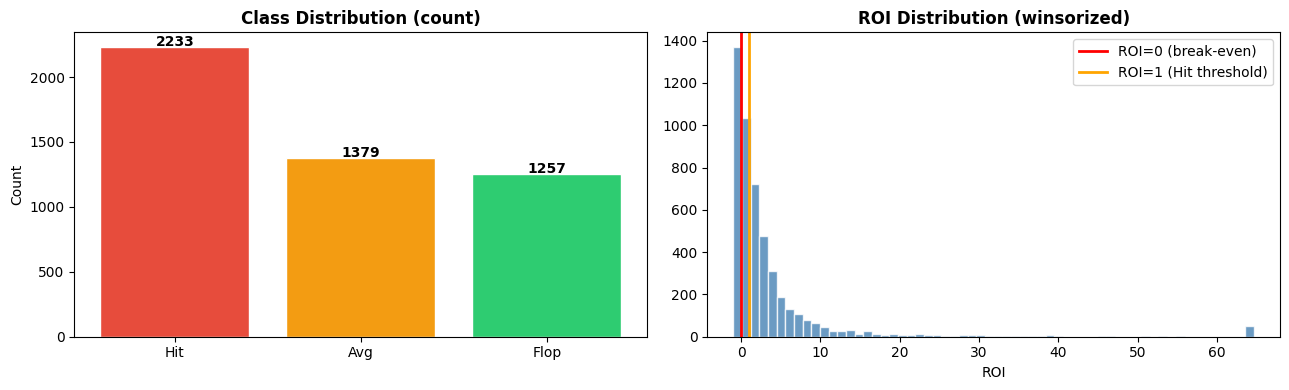

In [54]:
# ROI using inflation-adjusted numbers
df['roi'] = (df['adjusted_revenue'] - df['adjusted_budget']) / df['adjusted_budget']
df['roi'] = df['roi'].replace([np.inf, -np.inf], np.nan).fillna(0)

# Winsorize at 1%/99% — neutralises extreme outliers without losing rows
df['roi'] = np.array(winsorize(df['roi'], limits=[0.01, 0.01]))

# 3-class labelling — thresholds chosen so each class has ≥15% of data
def classify_3_labels(roi):
    if roi < 0:
        return 'Flop'
    elif roi < 1.5:      # 0-100% profit → Average
        return 'Avg'
    else:                # >100% profit → Hit
        return 'Hit'

df['success_label'] = df['roi'].apply(classify_3_labels)

print("Label distribution after winsorize:")
vc = df['success_label'].value_counts()
print(vc)
print(f"\nClass balance: {dict(round(vc / len(df) * 100, 1))} %")

# Visualise label distribution
fig, axes = plt.subplots(1, 2, figsize=(13, 4))
axes[0].bar(vc.index, vc.values, color=['#e74c3c','#f39c12','#2ecc71'], edgecolor='white')
axes[0].set_title('Class Distribution (count)', fontweight='bold')
axes[0].set_ylabel('Count')
for i, (k, v) in enumerate(vc.items()):
    axes[0].text(i, v + 5, str(v), ha='center', fontweight='bold')

axes[1].hist(df['roi'], bins=60, color='steelblue', edgecolor='white', alpha=0.8)
axes[1].axvline(0, color='red', lw=2, label='ROI=0 (break-even)')
axes[1].axvline(1, color='orange', lw=2, label='ROI=1 (Hit threshold)')
axes[1].set_title('ROI Distribution (winsorized)', fontweight='bold')
axes[1].set_xlabel('ROI'); axes[1].legend()
plt.tight_layout()
plt.savefig('label_distribution.png', dpi=150, bbox_inches='tight')
plt.show()

## STEP 5 — Budget Outlier Removal (IQR on adjusted_budget)

In [55]:
def remove_outliers_iqr(data, column):
    Q1 = data[column].quantile(0.25)
    Q3 = data[column].quantile(0.75)
    IQR = Q3 - Q1
    return data[(data[column] >= Q1 - 1.5*IQR) & (data[column] <= Q3 + 1.5*IQR)]

df = remove_outliers_iqr(df, 'adjusted_budget').reset_index(drop=True)
print(f"Rows after IQR budget filter: {len(df)}")
print("Final label distribution:")
print(df['success_label'].value_counts())

Rows after IQR budget filter: 4505
Final label distribution:
success_label
Hit     2037
Avg     1252
Flop    1216
Name: count, dtype: int64


## STEP 6 — Historical Talent Popularity (Leakage-Free)

**Key:** `get_past_metric()` only uses movies where `release_year < current_year`.  
This guarantees no future information leaks into training signals.

In [56]:
print("Calculating historical talent popularity (leakage-free)...")

def get_past_metric(name_str, current_year, role_col, dataframe):
    """Return past avg ROI for a person using only movies strictly before current_year."""
    if pd.isna(name_str) or str(name_str).strip() == '':
        return 0.0
    mask = (
        dataframe[role_col].str.contains(str(name_str), na=False, case=False, regex=False) &
        (dataframe['release_year'] < current_year)
    )
    past = dataframe.loc[mask, 'roi']
    return past.mean() if len(past) > 0 else 0.0

def get_past_count(name_str, current_year, role_col, dataframe):
    """Return number of past movies for a person (experience proxy)."""
    if pd.isna(name_str) or str(name_str).strip() == '':
        return 0
    mask = (
        dataframe[role_col].str.contains(str(name_str), na=False, case=False, regex=False) &
        (dataframe['release_year'] < current_year)
    )
    return mask.sum()

# Parse lead actors
df['lead_actor']       = df['actors'].str.split(',').str[0].str.strip().fillna('')
df['actor_1']          = df['actors'].str.split(',').str[1].str.strip().fillna('')
df['actor_2']          = df['actors'].str.split(',').str[2].str.strip().fillna('')
df['primary_producer'] = df['producers'].str.split(',').str[0].str.strip().fillna('')

# Talent ROI signals
df['director_popularity'] = [
    get_past_metric(r.director, r.release_year, 'director', df) for r in df.itertuples()
]
df['actor_popularity']    = [
    get_past_metric(r.lead_actor, r.release_year, 'lead_actor', df) for r in df.itertuples()
]
df['actor1_popularity']   = [
    get_past_metric(r.actor_1, r.release_year, 'lead_actor', df) for r in df.itertuples()
]
df['actor2_popularity']   = [
    get_past_metric(r.actor_2, r.release_year, 'lead_actor', df) for r in df.itertuples()
]
df['producer_popularity'] = [
    get_past_metric(r.primary_producer, r.release_year, 'producers', df) for r in df.itertuples()
]

# Talent experience signals (how many films have they done before?)
df['director_experience'] = [
    get_past_count(r.director, r.release_year, 'director', df) for r in df.itertuples()
]
df['actor_experience']    = [
    get_past_count(r.lead_actor, r.release_year, 'lead_actor', df) for r in df.itertuples()
]

df['avg_actor_popularity'] = df[[
    'actor_popularity', 'actor1_popularity', 'actor2_popularity'
]].mean(axis=1)

print("✅ Talent popularity & experience done.")

Calculating historical talent popularity (leakage-free)...
✅ Talent popularity & experience done.


## STEP 7 — Feature Engineering

In [57]:
print("Engineering features...")

# Budget / financial features
df['log_adj_budget'] = np.log1p(df['adjusted_budget'])
df['log_vote_count'] = np.log1p(df['vote_count'])

# Time features
df['decade']    = (df['release_year'] // 10) * 10
df['is_modern'] = (df['release_year'] >= 2000).astype(int)
df['is_summer'] = df['release_month'].isin([5, 6, 7, 8]).astype(int)   # summer blockbuster season
df['is_awards'] = df['release_month'].isin([10, 11, 12]).astype(int)   # awards season

# Genre features — top 15 Hollywood genres
selected_genres = [
    'Drama', 'Comedy', 'Thriller', 'Action', 'Adventure',
    'Crime', 'Romance', 'Horror', 'Science Fiction', 'Fantasy',
    'Family', 'Mystery', 'Animation', 'History', 'War'
]
df['genre_list']  = df['genres'].fillna('Unknown').str.split(', ')
df['genre_count'] = df['genre_list'].apply(len)

mlb = MultiLabelBinarizer(classes=selected_genres)
genre_encoded = mlb.fit_transform(df['genre_list'])
genre_df = pd.DataFrame(
    genre_encoded,
    columns=[f"genre_{c.replace(' ', '_')}" for c in selected_genres],
    index=df.index
)

# Derived interaction features
df['budget_popularity_ratio'] = df['log_adj_budget'] / (df['popularity'] + 1)
df['director_x_budget']       = df['director_popularity'] * df['log_adj_budget']
df['actor_x_budget']          = df['avg_actor_popularity'] * df['log_adj_budget']

print(f"Genre columns: {genre_df.shape[1]}")
print("✅ Feature engineering done.")

Engineering features...
Genre columns: 15
✅ Feature engineering done.


## STEP 8 — Dataset Assembly & Single Train/Val/Test Split

**Critical rule:** Only ONE split chain. All 9 models reuse the exact same `X_train`, `X_val`, `X_test`.

In [58]:
core_features = [
    # Time
    'release_year', 'decade', 'is_modern', 'is_summer', 'is_awards',
    # Financial
    'log_adj_budget',
    # Audience signals
    'popularity', 'vote_average', 'log_vote_count', 'has_rating',
    # Talent
    'director_popularity', 'director_experience',
    'actor_popularity', 'avg_actor_popularity', 'actor_experience',
    'producer_popularity',
    # Genre count
    'genre_count',
    # Interaction
    'budget_popularity_ratio', 'director_x_budget', 'actor_x_budget',
]

X = pd.concat([
    df[core_features].reset_index(drop=True),
    genre_df.reset_index(drop=True)
], axis=1).astype(float)

y = df['success_label'].reset_index(drop=True)
le = LabelEncoder()
y_encoded = le.fit_transform(y)
CLASSES = le.classes_
print("Classes:", CLASSES)
print(f"Total features: {X.shape[1]}")

# ── SINGLE split chain ──────────────────────────────────────────────
# 80% train+val, 20% test
X_trainval, X_test, y_trainval, y_test = train_test_split(
    X, y_encoded, test_size=0.20, random_state=42, stratify=y_encoded
)
# 80/20 of trainval → 64% train, 16% val of total
X_train, X_val, y_train, y_val = train_test_split(
    X_trainval, y_trainval, test_size=0.20, random_state=42, stratify=y_trainval
)

print(f"Train:      {X_train.shape}")
print(f"Validation: {X_val.shape}")
print(f"Test:       {X_test.shape}")

Classes: ['Avg' 'Flop' 'Hit']
Total features: 35
Train:      (2883, 35)
Validation: (721, 35)
Test:       (901, 35)


## STEP 9 — Model Definitions (All wrapped in ImbPipeline)

Every model: `StandardScaler → SMOTE → classifier`  
Tree models have depth/leaf constraints to prevent memorisation.  
XGBoost & LightGBM tuned for generalisation via `reg_lambda`, `min_child_weight`, `subsample`.

In [59]:
def make_pipeline(classifier):
    """Wrap any classifier: StandardScaler → SMOTE (train-only) → classifier."""
    return ImbPipeline([
        ('scaler', StandardScaler()),
        ('smote',  SMOTE(random_state=42, k_neighbors=3)),
        ('clf',    classifier)
    ])

n_classes = len(CLASSES)

model_defs = {
    "Logistic Regression": LogisticRegression(
        C=0.5, max_iter=2000, class_weight='balanced',
        solver='lbfgs', multi_class='multinomial', random_state=42
    ),
    "Decision Tree": DecisionTreeClassifier(
        max_depth=6, min_samples_leaf=15,
        class_weight='balanced', random_state=42
    ),
    "Random Forest": RandomForestClassifier(
        n_estimators=300, max_depth=12, min_samples_leaf=8,
        max_features='sqrt', class_weight='balanced',
        random_state=42, n_jobs=-1
    ),
    "Gradient Boosting": GradientBoostingClassifier(
        n_estimators=200, max_depth=4, learning_rate=0.05,
        min_samples_leaf=15, subsample=0.8, random_state=42
    ),
    "SVM": SVC(
        C=1.0, kernel='rbf', class_weight='balanced',
        probability=True, random_state=42
    ),
    "KNN": KNeighborsClassifier(
        n_neighbors=15, weights='distance', metric='euclidean'
    ),
    "XGBoost": xgb.XGBClassifier(
        n_estimators=300, max_depth=4, learning_rate=0.05,
        subsample=0.8, colsample_bytree=0.8,
        reg_alpha=0.1, reg_lambda=1.0,
        min_child_weight=5,
        use_label_encoder=False,
        eval_metric='mlogloss',
        random_state=42, n_jobs=-1
    ),
    "LightGBM": lgb.LGBMClassifier(
        n_estimators=300, max_depth=6, learning_rate=0.05,
        num_leaves=31, subsample=0.8, colsample_bytree=0.8,
        reg_alpha=0.1, reg_lambda=1.0,
        min_child_samples=20,
        class_weight='balanced',
        random_state=42, n_jobs=-1, verbose=-1
    ),
}

pipelines = {name: make_pipeline(clf) for name, clf in model_defs.items()}
print("✅ Pipelines defined for:", list(pipelines.keys()))

✅ Pipelines defined for: ['Logistic Regression', 'Decision Tree', 'Random Forest', 'Gradient Boosting', 'SVM', 'KNN', 'XGBoost', 'LightGBM']


## STEP 10 — Train All 8 Models & Compute Full Metrics

In [60]:
print("Training all 8 models... (may take 3-5 min)")

results = []
trained_pipelines = {}

cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)

for name, pipe in pipelines.items():
    print(f"  → {name}...")

    pipe.fit(X_train, y_train)
    trained_pipelines[name] = pipe

    y_val_pred  = pipe.predict(X_val)
    y_val_proba = pipe.predict_proba(X_val)
    y_test_pred  = pipe.predict(X_test)
    y_test_proba = pipe.predict_proba(X_test)

    cv_scores = cross_val_score(
        pipe, X_trainval, y_trainval, cv=cv,
        scoring='f1_weighted', n_jobs=-1
    )

    y_val_bin  = label_binarize(y_val,  classes=range(len(CLASSES)))
    y_test_bin = label_binarize(y_test, classes=range(len(CLASSES)))
    auc_val  = roc_auc_score(y_val_bin,  y_val_proba,  multi_class='ovr', average='macro')
    auc_test = roc_auc_score(y_test_bin, y_test_proba, multi_class='ovr', average='macro')

    y_train_pred = pipe.predict(X_train)
    train_acc = accuracy_score(y_train, y_train_pred)
    val_acc   = accuracy_score(y_val,   y_val_pred)
    test_acc  = accuracy_score(y_test,  y_test_pred)

    results.append({
        "Model":         name,
        "Train Acc":     round(train_acc, 4),
        "Val Acc":       round(val_acc,   4),
        "Test Acc":      round(test_acc,  4),
        "Val Precision": round(precision_score(y_val,  y_val_pred,  average='weighted', zero_division=0), 4),
        "Val Recall":    round(recall_score(y_val,     y_val_pred,  average='weighted'), 4),
        "Val F1":        round(f1_score(y_val,         y_val_pred,  average='weighted'), 4),
        "Test F1":       round(f1_score(y_test,        y_test_pred, average='weighted'), 4),
        "Val AUC":       round(auc_val,  4),
        "Test AUC":      round(auc_test, 4),
        "CV F1 Mean":    round(cv_scores.mean(), 4),
        "CV F1 Std":     round(cv_scores.std(),  4),
        "Overfit Gap":   round(train_acc - val_acc, 4),
    })

    # Store predictions for later plots
    pipe._y_val_pred   = y_val_pred
    pipe._y_val_proba  = y_val_proba
    pipe._y_test_pred  = y_test_pred
    pipe._y_test_proba = y_test_proba

results_df = pd.DataFrame(results).sort_values("Val F1", ascending=False).reset_index(drop=True)
print("\n✅ All 8 models trained.")
print(results_df.to_string(index=False))

Training all 8 models... (may take 3-5 min)
  → Logistic Regression...
  → Decision Tree...
  → Random Forest...
  → Gradient Boosting...
  → SVM...
  → KNN...
  → XGBoost...
  → LightGBM...

✅ All 8 models trained.
              Model  Train Acc  Val Acc  Test Acc  Val Precision  Val Recall  Val F1  Test F1  Val AUC  Test AUC  CV F1 Mean  CV F1 Std  Overfit Gap
           LightGBM     0.9438   0.5895    0.5860         0.5866      0.5895  0.5874   0.5816   0.7412    0.7474      0.5793     0.0124       0.3543
                SVM     0.7336   0.5728    0.5816         0.5809      0.5728  0.5744   0.5814   0.7341    0.7520      0.5770     0.0234       0.1608
  Gradient Boosting     0.7971   0.5714    0.5738         0.5752      0.5714  0.5725   0.5699   0.7417    0.7526      0.5929     0.0165       0.2257
            XGBoost     0.7971   0.5728    0.5805         0.5737      0.5728  0.5719   0.5736   0.7432    0.7560      0.5894     0.0109       0.2243
      Random Forest     0.7832   0.5714

## STEP 11 — Stacking Ensemble (Meta-learner on top of 8 base models)

In [61]:
print("Building Stacking Ensemble...")

# Base estimators for stacking (raw classifiers, not ImbPipelines)
# We wrap the FULL pipeline as the base estimator so SMOTE is applied internally
stacking_estimators = [
    ('lr',  ImbPipeline([('sc', StandardScaler()), ('sm', SMOTE(random_state=42, k_neighbors=3)),
                         ('clf', LogisticRegression(C=0.5, max_iter=2000, class_weight='balanced', random_state=42))])),
    ('rf',  ImbPipeline([('sc', StandardScaler()), ('sm', SMOTE(random_state=42, k_neighbors=3)),
                         ('clf', RandomForestClassifier(n_estimators=200, max_depth=10, min_samples_leaf=8,
                                                         class_weight='balanced', random_state=42, n_jobs=-1))])),
    ('gb',  ImbPipeline([('sc', StandardScaler()), ('sm', SMOTE(random_state=42, k_neighbors=3)),
                         ('clf', GradientBoostingClassifier(n_estimators=150, max_depth=4,
                                                             learning_rate=0.05, subsample=0.8, random_state=42))])),
    ('xgb', ImbPipeline([('sc', StandardScaler()), ('sm', SMOTE(random_state=42, k_neighbors=3)),
                         ('clf', xgb.XGBClassifier(n_estimators=200, max_depth=4, learning_rate=0.05,
                                                    subsample=0.8, colsample_bytree=0.8,
                                                    reg_lambda=1.0, min_child_weight=5,
                                                    use_label_encoder=False, eval_metric='mlogloss',
                                                    random_state=42, n_jobs=-1))])),
    ('lgb', ImbPipeline([('sc', StandardScaler()), ('sm', SMOTE(random_state=42, k_neighbors=3)),
                         ('clf', lgb.LGBMClassifier(n_estimators=200, max_depth=6, learning_rate=0.05,
                                                    num_leaves=31, subsample=0.8, colsample_bytree=0.8,
                                                    class_weight='balanced', random_state=42, n_jobs=-1, verbose=-1))])),
]

# Meta-learner: Logistic Regression with low C to avoid overfitting
meta_learner = LogisticRegression(C=0.3, max_iter=1000, class_weight='balanced',
                                   solver='lbfgs', multi_class='multinomial', random_state=42)

stack_clf = StackingClassifier(
    estimators=stacking_estimators,
    final_estimator=meta_learner,
    cv=StratifiedKFold(n_splits=5, shuffle=True, random_state=42),
    stack_method='predict_proba',
    n_jobs=-1
)

print("Fitting stacking ensemble on X_train...")
stack_clf.fit(X_train, y_train)

# Evaluate stacking
y_val_pred_s  = stack_clf.predict(X_val)
y_val_proba_s = stack_clf.predict_proba(X_val)
y_test_pred_s  = stack_clf.predict(X_test)
y_test_proba_s = stack_clf.predict_proba(X_test)

cv_s = cross_val_score(stack_clf, X_trainval, y_trainval, cv=cv, scoring='f1_weighted', n_jobs=-1)

y_val_bin  = label_binarize(y_val,  classes=range(len(CLASSES)))
y_test_bin = label_binarize(y_test, classes=range(len(CLASSES)))

train_acc_s = accuracy_score(y_train, stack_clf.predict(X_train))
val_acc_s   = accuracy_score(y_val,   y_val_pred_s)
test_acc_s  = accuracy_score(y_test,  y_test_pred_s)

stack_row = {
    "Model":         "Stacking Ensemble",
    "Train Acc":     round(train_acc_s, 4),
    "Val Acc":       round(val_acc_s,   4),
    "Test Acc":      round(test_acc_s,  4),
    "Val Precision": round(precision_score(y_val, y_val_pred_s, average='weighted', zero_division=0), 4),
    "Val Recall":    round(recall_score(y_val, y_val_pred_s, average='weighted'), 4),
    "Val F1":        round(f1_score(y_val, y_val_pred_s, average='weighted'), 4),
    "Test F1":       round(f1_score(y_test, y_test_pred_s, average='weighted'), 4),
    "Val AUC":       round(roc_auc_score(y_val_bin, y_val_proba_s, multi_class='ovr', average='macro'), 4),
    "Test AUC":      round(roc_auc_score(y_test_bin, y_test_proba_s, multi_class='ovr', average='macro'), 4),
    "CV F1 Mean":    round(cv_s.mean(), 4),
    "CV F1 Std":     round(cv_s.std(),  4),
    "Overfit Gap":   round(train_acc_s - val_acc_s, 4),
}

# Store for later
stack_clf._y_val_pred   = y_val_pred_s
stack_clf._y_val_proba  = y_val_proba_s
stack_clf._y_test_pred  = y_test_pred_s
stack_clf._y_test_proba = y_test_proba_s

results_df = pd.concat([results_df, pd.DataFrame([stack_row])], ignore_index=True) \
               .sort_values("Val F1", ascending=False).reset_index(drop=True)
trained_pipelines["Stacking Ensemble"] = stack_clf

print("\n✅ Stacking Ensemble done.")
print(f"  Val F1  = {stack_row['Val F1']:.4f}")
print(f"  Test F1 = {stack_row['Test F1']:.4f}")
print(f"  Overfit Gap = {stack_row['Overfit Gap']:.4f}")

Building Stacking Ensemble...
Fitting stacking ensemble on X_train...

✅ Stacking Ensemble done.
  Val F1  = 0.5774
  Test F1 = 0.5878
  Overfit Gap = 0.2142


## STEP 12 — Results Summary Table (All 9 Models)

In [62]:
display_cols = [
    "Model", "Val Acc", "Val Precision", "Val Recall", "Val F1",
    "Test Acc", "Test F1", "Val AUC", "Test AUC",
    "CV F1 Mean", "CV F1 Std", "Overfit Gap"
]

styled = results_df[display_cols].style \
    .background_gradient(subset=["Val F1", "Test F1", "Val AUC", "Test AUC", "CV F1 Mean"], cmap='RdYlGn') \
    .background_gradient(subset=["Overfit Gap"], cmap='RdYlGn_r') \
    .format({c: "{:.4f}" for c in display_cols if c != "Model"}) \
    .set_caption("📊 Full Model Comparison — Validation & Test Metrics (9 Models)")

styled

,Model,Val Acc,Val Precision,Val Recall,Val F1,Test Acc,Test F1,Val AUC,Test AUC,CV F1 Mean,CV F1 Std,Overfit Gap
0,LightGBM,0.5895,0.5866,0.5895,0.5874,0.5860,0.5816,0.7412,0.7474,0.5793,0.0124,0.3543
1,Stacking Ensemble,0.5742,0.5878,0.5742,0.5774,0.5860,0.5878,0.7479,0.7632,0.5894,0.0171,0.2142
2,SVM,0.5728,0.5809,0.5728,0.5744,0.5816,0.5814,0.7341,0.7520,0.5770,0.0234,0.1608
3,Gradient Boosting,0.5714,0.5752,0.5714,0.5725,0.5738,0.5699,0.7417,0.7526,0.5929,0.0165,0.2257
4,XGBoost,0.5728,0.5737,0.5728,0.5719,0.5805,0.5736,0.7432,0.7560,0.5894,0.0109,0.2243
5,Random Forest,0.5714,0.5725,0.5714,0.5711,0.5749,0.5696,0.7377,0.7478,0.5776,0.0149,0.2118
6,Logistic Regression,0.5423,0.5554,0.5423,0.5441,0.5805,0.5800,0.7060,0.7295,0.5717,0.0138,0.0467
7,Decision Tree,0.5021,0.5334,0.5021,0.5118,0.5427,0.5483,0.6848,0.6969,0.5165,0.0128,0.0969
8,KNN,0.4674,0.5038,0.4674,0.4774,0.4772,0.4858,0.6582,0.6640,0.4748,0.0123,0.5326


## STEP 13 — Confusion Matrices (All 9 Models)

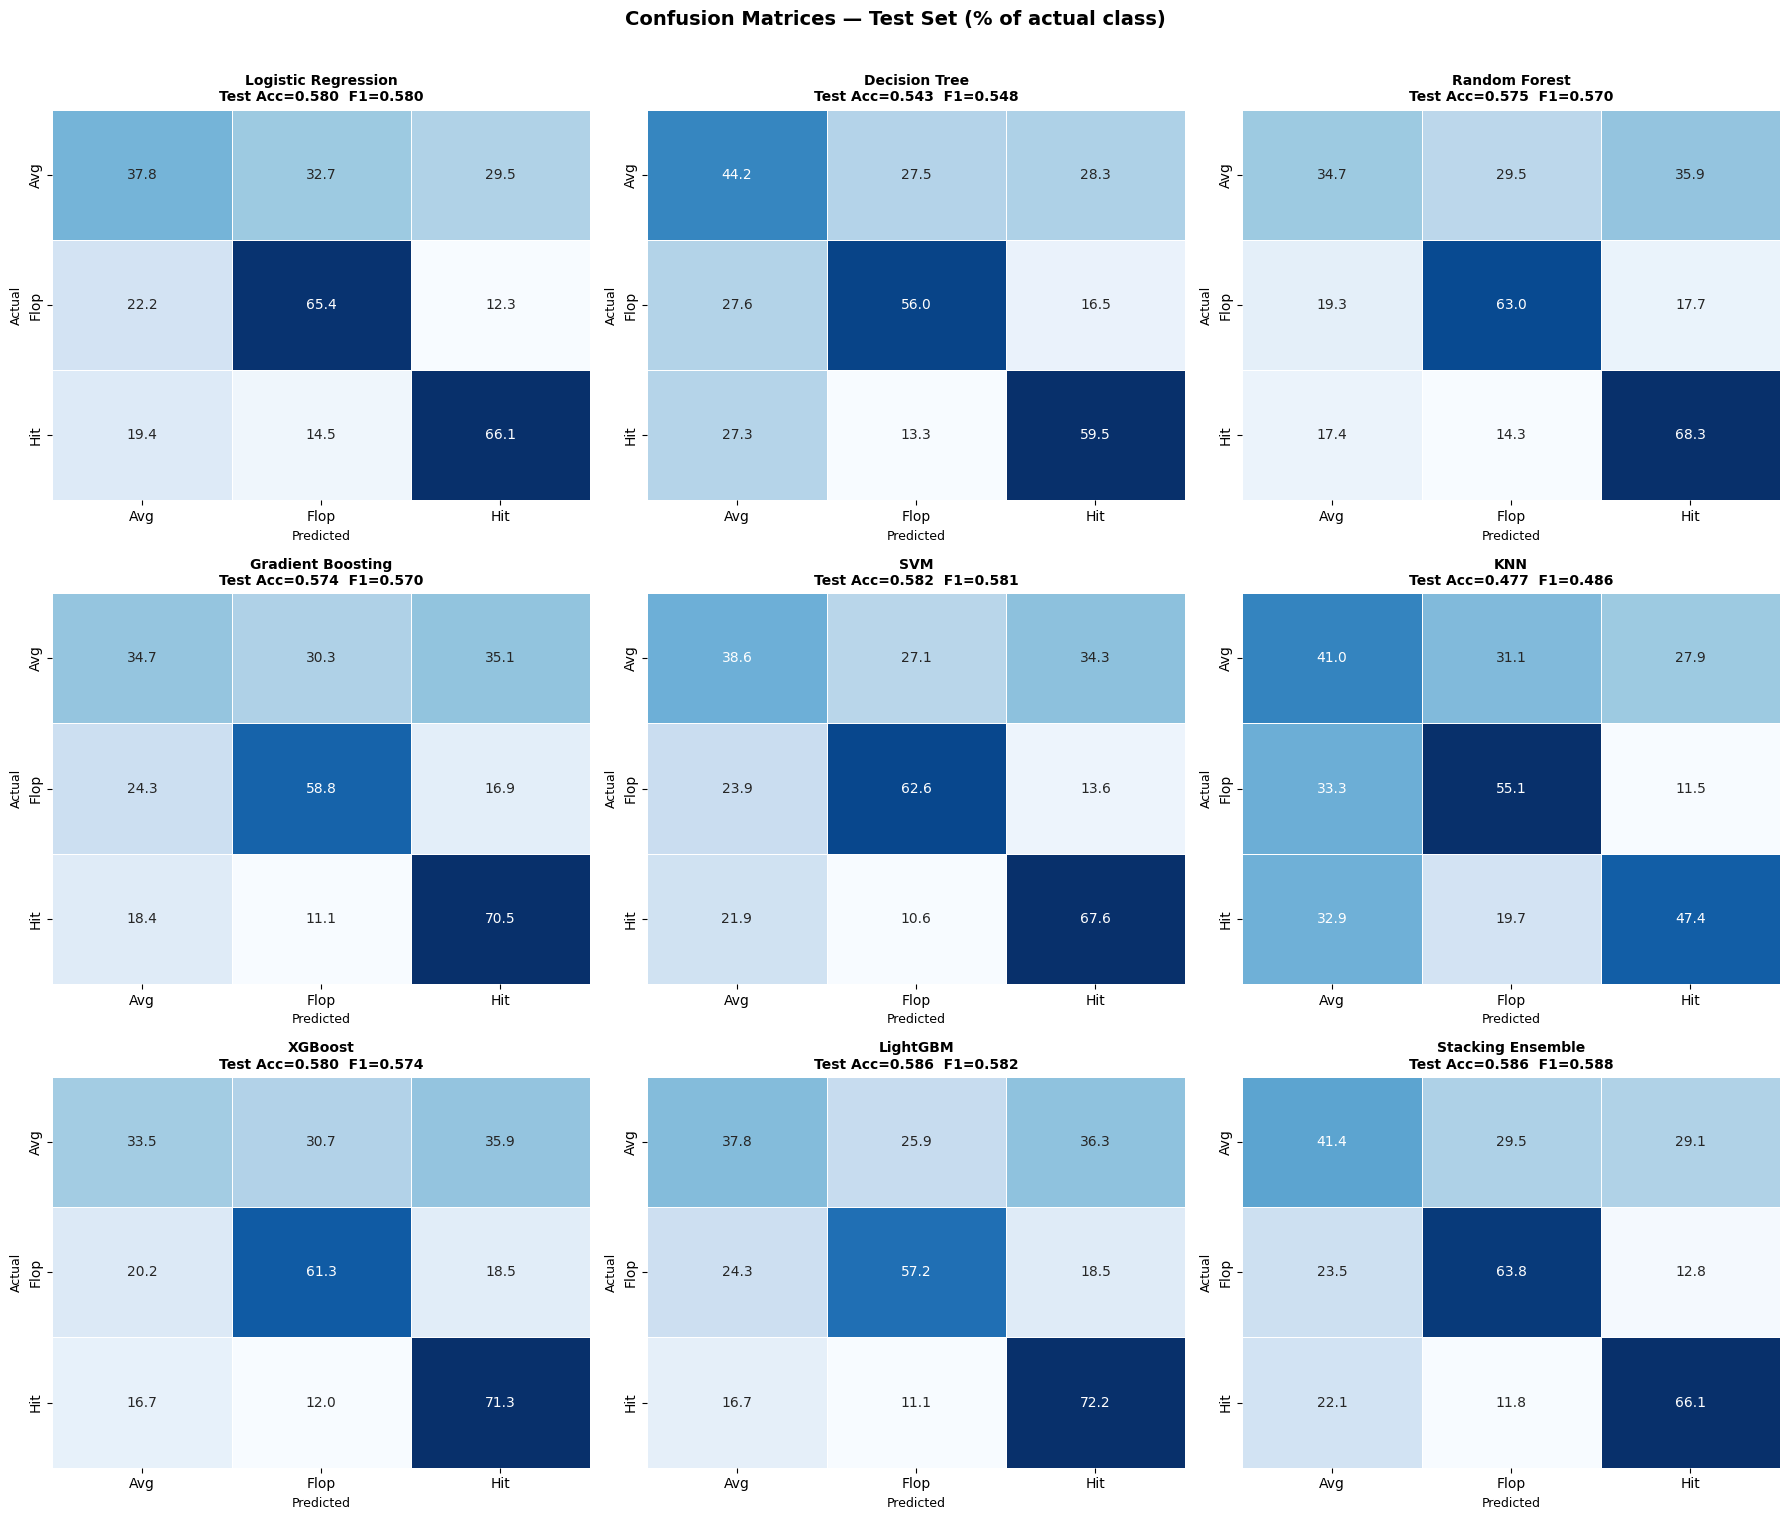

Saved: confusion_matrices.png


In [63]:
n_models = len(trained_pipelines)
n_cols = 3
n_rows = (n_models + n_cols - 1) // n_cols

fig, axes = plt.subplots(n_rows, n_cols, figsize=(18, n_rows * 5))
axes = axes.flatten()

for i, (name, pipe) in enumerate(trained_pipelines.items()):
    cm = confusion_matrix(y_test, pipe._y_test_pred)
    cm_pct = cm.astype(float) / cm.sum(axis=1, keepdims=True) * 100

    sns.heatmap(cm_pct, annot=True, fmt='.1f', cmap='Blues',
                xticklabels=CLASSES, yticklabels=CLASSES,
                ax=axes[i], cbar=False, linewidths=0.5)

    acc = accuracy_score(y_test, pipe._y_test_pred)
    f1  = f1_score(y_test,      pipe._y_test_pred, average='weighted')
    axes[i].set_title(f"{name}\nTest Acc={acc:.3f}  F1={f1:.3f}", fontsize=10, fontweight='bold')
    axes[i].set_xlabel("Predicted", fontsize=9)
    axes[i].set_ylabel("Actual",    fontsize=9)

# Hide empty subplots
for j in range(i + 1, len(axes)):
    axes[j].set_visible(False)

plt.suptitle("Confusion Matrices — Test Set (% of actual class)", fontsize=14, fontweight='bold', y=1.01)
plt.tight_layout()
plt.savefig("confusion_matrices.png", dpi=150, bbox_inches='tight')
plt.show()
print("Saved: confusion_matrices.png")

In [81]:
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score, roc_auc_score
import pandas as pd
import numpy as np

selected_models = [
    'Stacking Ensemble',
    'LightGBM',
    'SVM',
    'Logistic Regression'   # replace with 'XGBoost' if needed
]

results = []

for name in selected_models:
    model = trained_pipelines[name]
    
    # Predictions
    y_pred = model.predict(X_test)
    
    # Metrics
    acc = accuracy_score(y_test, y_pred)
    prec = precision_score(y_test, y_pred, average='macro')
    rec = recall_score(y_test, y_pred, average='macro')
    f1 = f1_score(y_test, y_pred, average='macro')
    
    # AUC
    if hasattr(model, "predict_proba"):
        y_proba = model.predict_proba(X_test)
        auc = roc_auc_score(y_test, y_proba, multi_class='ovr')
    else:
        auc = np.nan
    
    results.append([name, acc, prec, rec, f1, auc])

results_df = pd.DataFrame(results, columns=[
    'Model', 'Accuracy', 'Precision', 'Recall', 'F1 Score', 'AUC'
])

# Sort best first
results_df = results_df.sort_values(by='F1 Score', ascending=False)

results_df

,Model,Accuracy,Precision,Recall,F1 Score,AUC
0,Stacking Ensemble,0.586016,0.565030,0.571045,0.566747,0.763228
2,SVM,0.581576,0.557819,0.562548,0.559784,0.751992
3,Logistic Regression,0.580466,0.555949,0.564580,0.557346,0.729459
1,LightGBM,0.586016,0.556627,0.557620,0.556414,0.747443


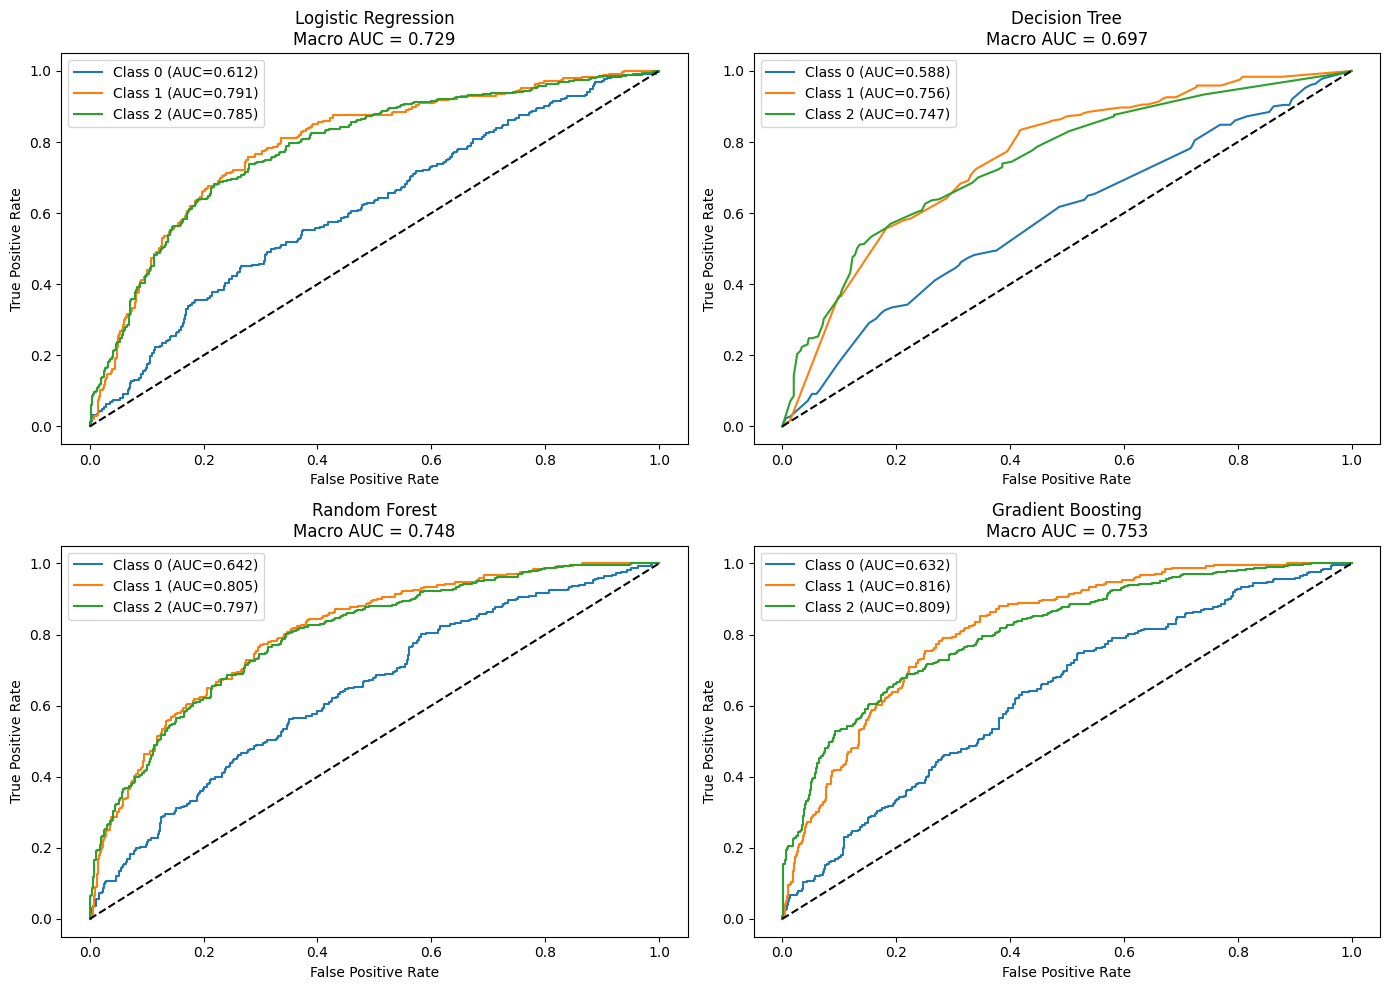

In [85]:
from sklearn.metrics import roc_curve, auc
from sklearn.preprocessing import label_binarize
import matplotlib.pyplot as plt
import numpy as np

selected_models = [
    'Logistic Regression',
    'Decision Tree',
    'Random Forest',
    'Gradient Boosting'
]

# Convert labels for multiclass ROC
classes = np.unique(y_test)
y_test_bin = label_binarize(y_test, classes=classes)

plt.figure(figsize=(14, 10))

for i, name in enumerate(selected_models):
    model = trained_pipelines[name]
    
    # Probabilities
    y_score = model.predict_proba(X_test)
    
    fpr, tpr, roc_auc = {}, {}, {}
    
    for j in range(len(classes)):
        fpr[j], tpr[j], _ = roc_curve(y_test_bin[:, j], y_score[:, j])
        roc_auc[j] = auc(fpr[j], tpr[j])
    
    macro_auc = np.mean(list(roc_auc.values()))
    
    plt.subplot(2, 2, i+1)
    
    for j in range(len(classes)):
        plt.plot(fpr[j], tpr[j], label=f'Class {j} (AUC={roc_auc[j]:.3f})')
    
    plt.plot([0, 1], [0, 1], 'k--')
    
    plt.title(f"{name}\nMacro AUC = {macro_auc:.3f}")
    plt.xlabel("False Positive Rate")
    plt.ylabel("True Positive Rate")
    plt.legend()

plt.tight_layout()
plt.show()

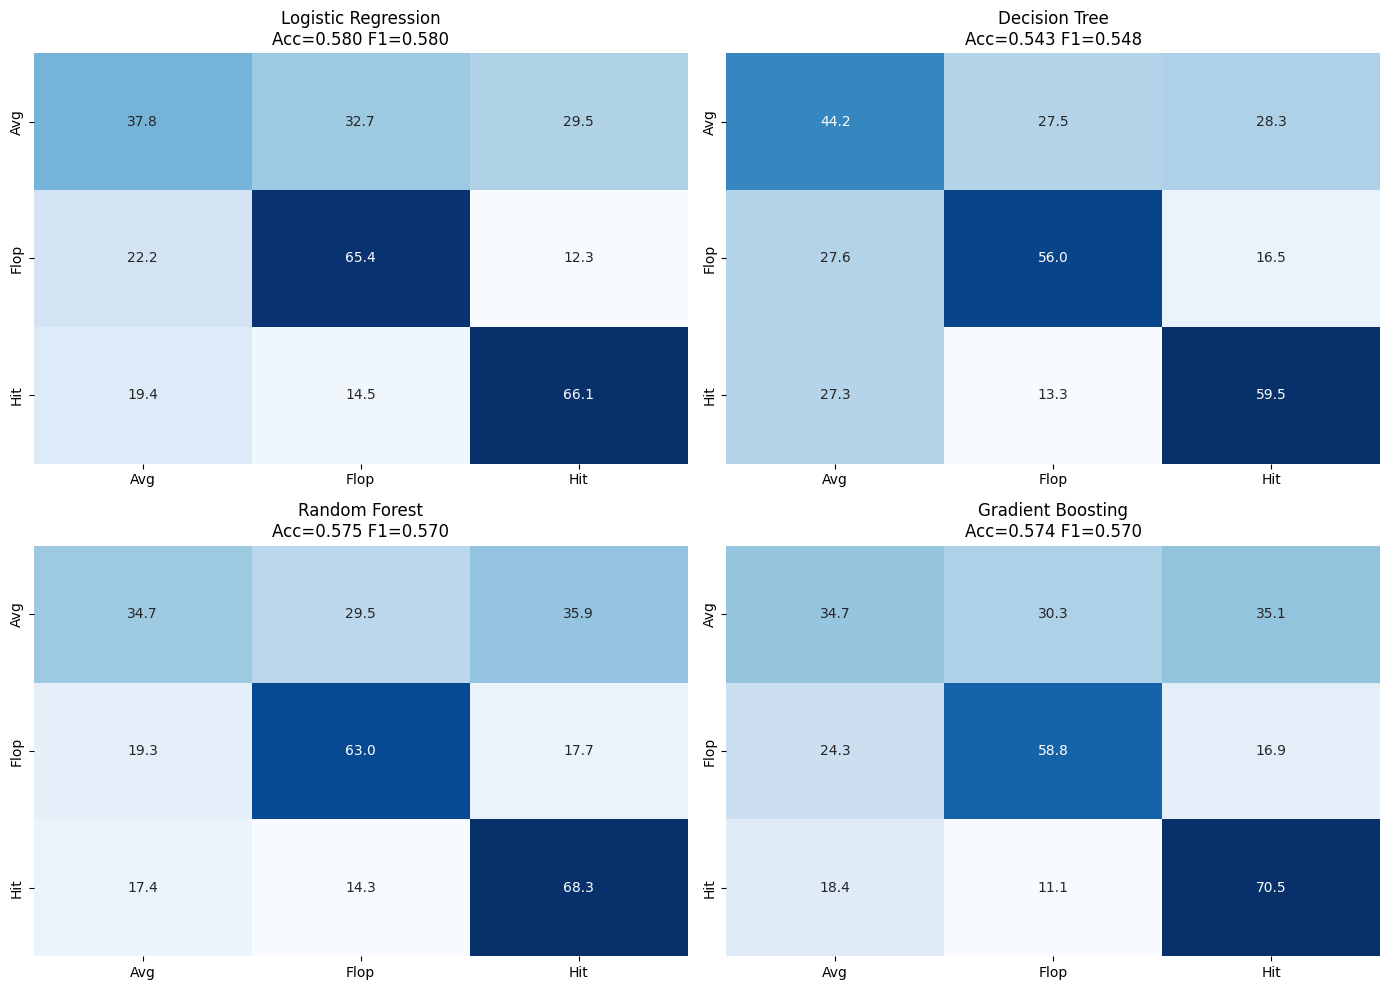

In [86]:
from sklearn.metrics import confusion_matrix, accuracy_score, f1_score
import seaborn as sns
import matplotlib.pyplot as plt

selected_models = [
    'Logistic Regression',
    'Decision Tree',
    'Random Forest',
    'Gradient Boosting'
]

fig, axes = plt.subplots(2, 2, figsize=(14, 10))
axes = axes.flatten()

for i, name in enumerate(selected_models):
    model = trained_pipelines[name]
    y_pred = model.predict(X_test)
    
    cm = confusion_matrix(y_test, y_pred)
    cm_pct = cm.astype(float) / cm.sum(axis=1, keepdims=True) * 100
    
    sns.heatmap(cm_pct, annot=True, fmt='.1f', cmap='Blues',
                xticklabels=CLASSES, yticklabels=CLASSES,
                ax=axes[i], cbar=False)
    
    acc = accuracy_score(y_test, y_pred)
    f1 = f1_score(y_test, y_pred, average='weighted')
    
    axes[i].set_title(f"{name}\nAcc={acc:.3f} F1={f1:.3f}")

plt.tight_layout()
plt.show()

In [87]:
from sklearn.metrics import classification_report

# Get model
lr = trained_pipelines['Logistic Regression']

# Predictions
y_pred_lr = lr.predict(X_test)

# Print report
print("Logistic Regression")
print("="*70)
print(classification_report(y_test, y_pred_lr))

Logistic Regression
              precision    recall  f1-score   support

           0       0.42      0.38      0.40       251
           1       0.53      0.65      0.59       243
           2       0.72      0.66      0.69       407

    accuracy                           0.58       901
   macro avg       0.56      0.56      0.56       901
weighted avg       0.58      0.58      0.58       901



In [83]:
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score, roc_auc_score
import pandas as pd
import numpy as np

selected_models = [
    'Logistic Regression',
    'Decision Tree',
    'Random Forest',
    'Gradient Boosting'
]

results = []

for name in selected_models:
    model = trained_pipelines[name]
    
    # Predictions
    y_pred = model.predict(X_test)
    
    # Metrics (macro for multiclass)
    acc = accuracy_score(y_test, y_pred)
    prec = precision_score(y_test, y_pred, average='macro')
    rec = recall_score(y_test, y_pred, average='macro')
    f1 = f1_score(y_test, y_pred, average='macro')
    
    # AUC
    y_proba = model.predict_proba(X_test)
    auc = roc_auc_score(y_test, y_proba, multi_class='ovr')
    
    results.append([name, acc, prec, rec, f1, auc])

results_df = pd.DataFrame(results, columns=[
    'Model', 'Accuracy', 'Precision', 'Recall', 'F1 Score', 'AUC'
])

results_df.sort_values(by='F1 Score', ascending=False)

,Model,Accuracy,Precision,Recall,F1 Score,AUC
0,Logistic Regression,0.580466,0.555949,0.564580,0.557346,0.729459
2,Random Forest,0.574917,0.545877,0.553097,0.546944,0.747779
3,Gradient Boosting,0.573807,0.541745,0.546750,0.543398,0.752615
1,Decision Tree,0.542730,0.531577,0.532165,0.529929,0.696860


## STEP 14 — ROC Curves — One-vs-Rest, per class (All 9 Models)

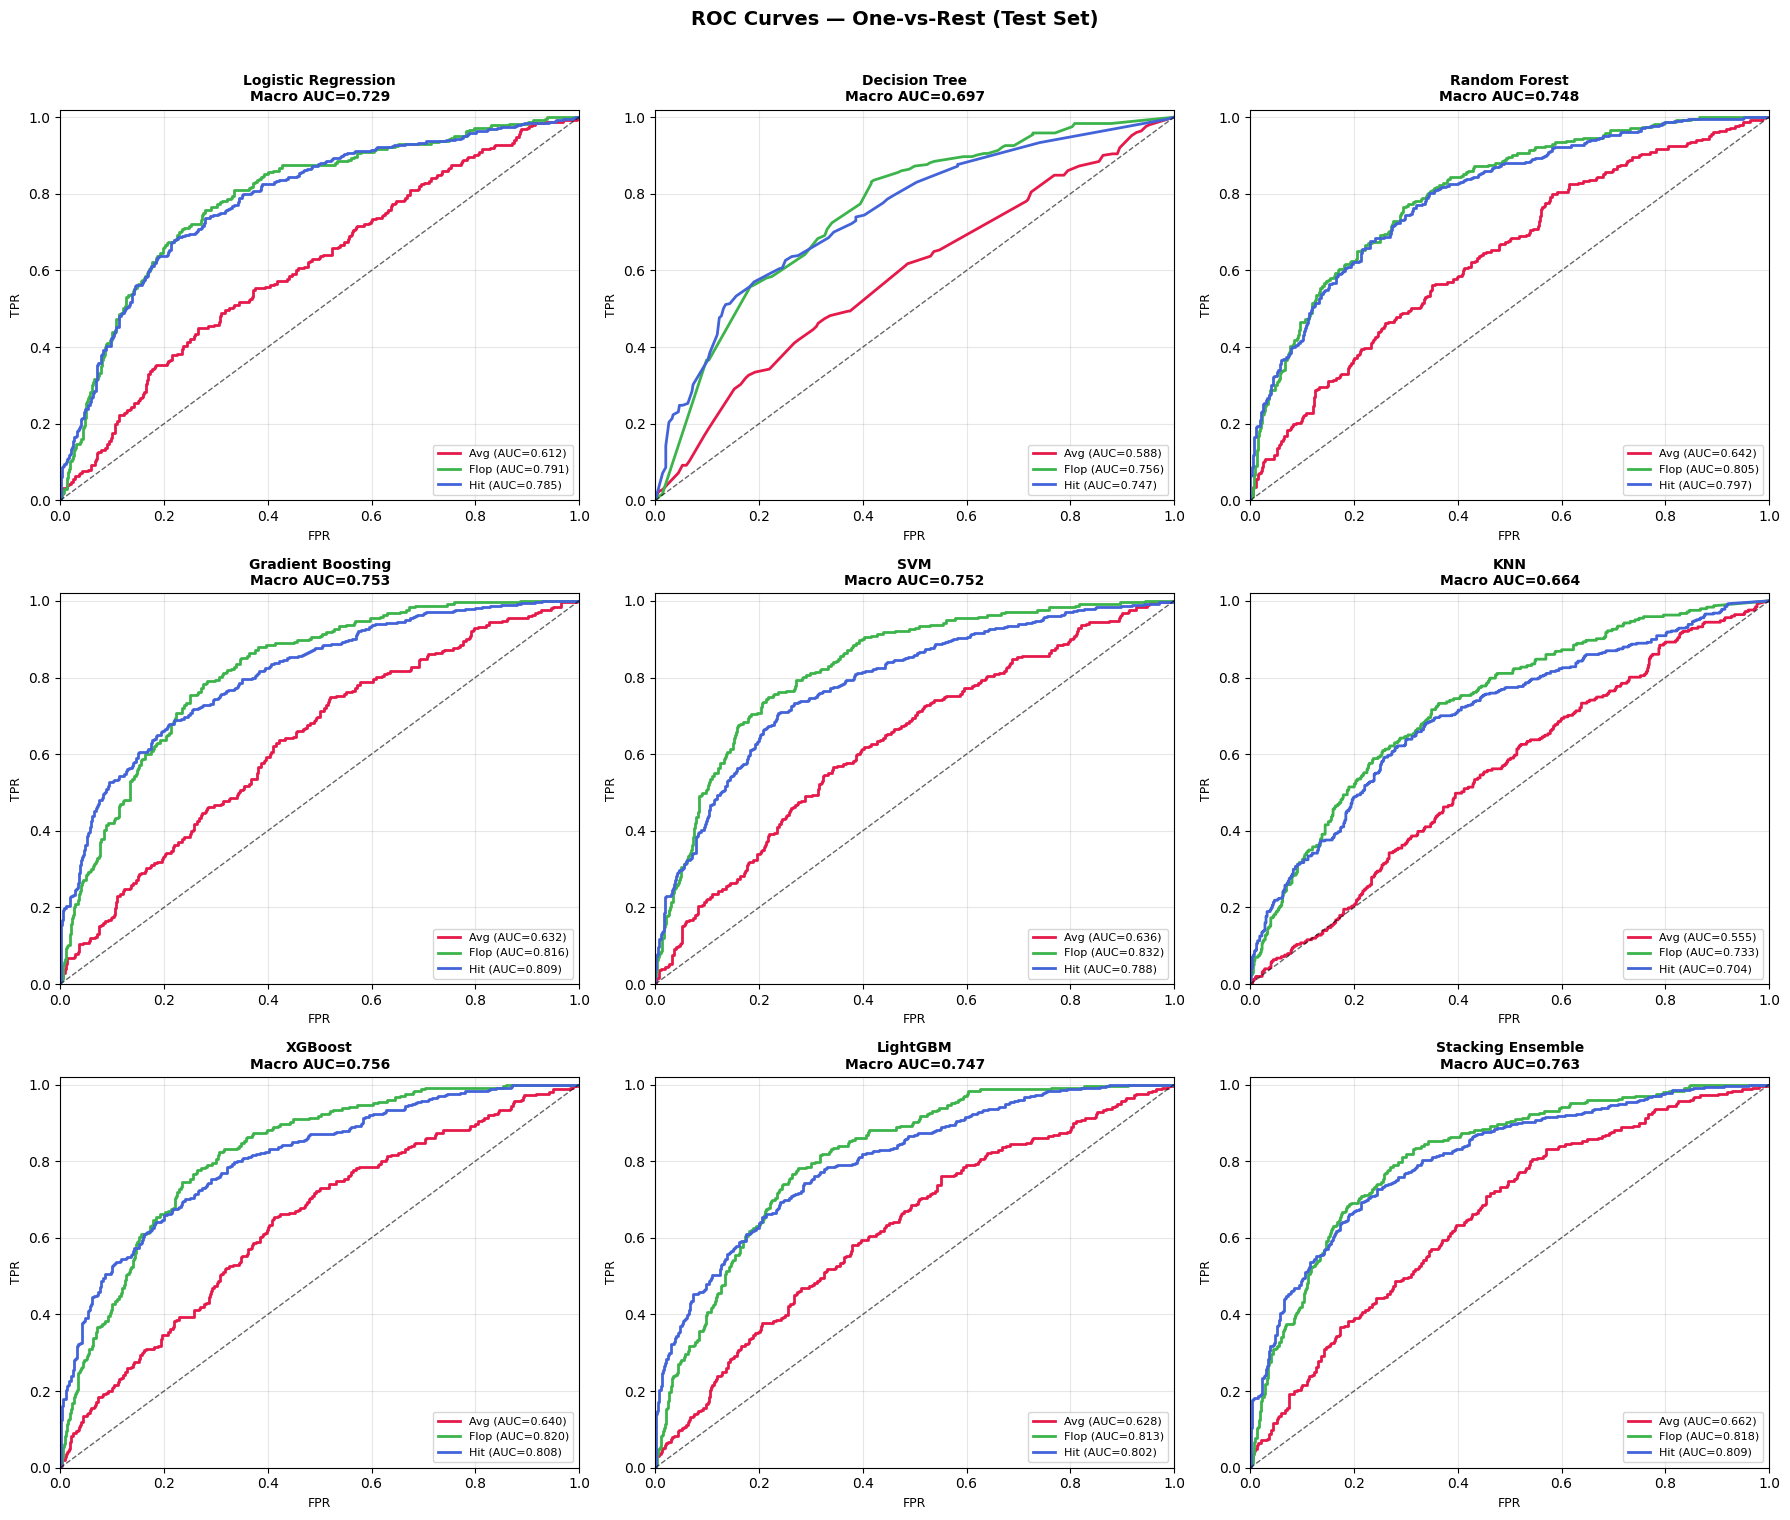

Saved: roc_curves.png


In [64]:
fig, axes = plt.subplots(n_rows, n_cols, figsize=(18, n_rows * 5))
axes = axes.flatten()
colors = ['#e6194b', '#3cb44b', '#4363d8']

y_test_bin = label_binarize(y_test, classes=range(len(CLASSES)))

for i, (name, pipe) in enumerate(trained_pipelines.items()):
    ax = axes[i]
    y_proba = pipe._y_test_proba
    macro_auc_vals = []

    for j, cls in enumerate(CLASSES):
        fpr, tpr, _ = roc_curve(y_test_bin[:, j], y_proba[:, j])
        roc_auc = auc(fpr, tpr)
        macro_auc_vals.append(roc_auc)
        ax.plot(fpr, tpr, color=colors[j], lw=2, label=f"{cls} (AUC={roc_auc:.3f})")

    ax.plot([0, 1], [0, 1], 'k--', lw=1, alpha=0.6)
    ax.set_xlim([0, 1]); ax.set_ylim([0, 1.02])
    ax.set_xlabel("FPR", fontsize=9); ax.set_ylabel("TPR", fontsize=9)
    ax.set_title(f"{name}\nMacro AUC={np.mean(macro_auc_vals):.3f}", fontsize=10, fontweight='bold')
    ax.legend(loc='lower right', fontsize=8)
    ax.grid(alpha=0.3)

for j in range(i + 1, len(axes)):
    axes[j].set_visible(False)

plt.suptitle("ROC Curves — One-vs-Rest (Test Set)", fontsize=14, fontweight='bold', y=1.01)
plt.tight_layout()
plt.savefig("roc_curves.png", dpi=150, bbox_inches='tight')
plt.show()
print("Saved: roc_curves.png")

## STEP 15 — Per-Class Classification Reports (All 9 Models)

In [65]:
for name, pipe in trained_pipelines.items():
    print(f"\n{'='*65}")
    print(f"  {name}")
    print(f"{'='*65}")
    print(classification_report(y_test, pipe._y_test_pred, target_names=CLASSES))


  Logistic Regression
              precision    recall  f1-score   support

         Avg       0.42      0.38      0.40       251
        Flop       0.53      0.65      0.59       243
         Hit       0.72      0.66      0.69       407

    accuracy                           0.58       901
   macro avg       0.56      0.56      0.56       901
weighted avg       0.58      0.58      0.58       901


  Decision Tree
              precision    recall  f1-score   support

         Avg       0.38      0.44      0.41       251
        Flop       0.53      0.56      0.54       243
         Hit       0.69      0.59      0.64       407

    accuracy                           0.54       901
   macro avg       0.53      0.53      0.53       901
weighted avg       0.56      0.54      0.55       901


  Random Forest
              precision    recall  f1-score   support

         Avg       0.42      0.35      0.38       251
        Flop       0.54      0.63      0.58       243
         Hit      

## STEP 16 — Metric Comparison Bar Charts

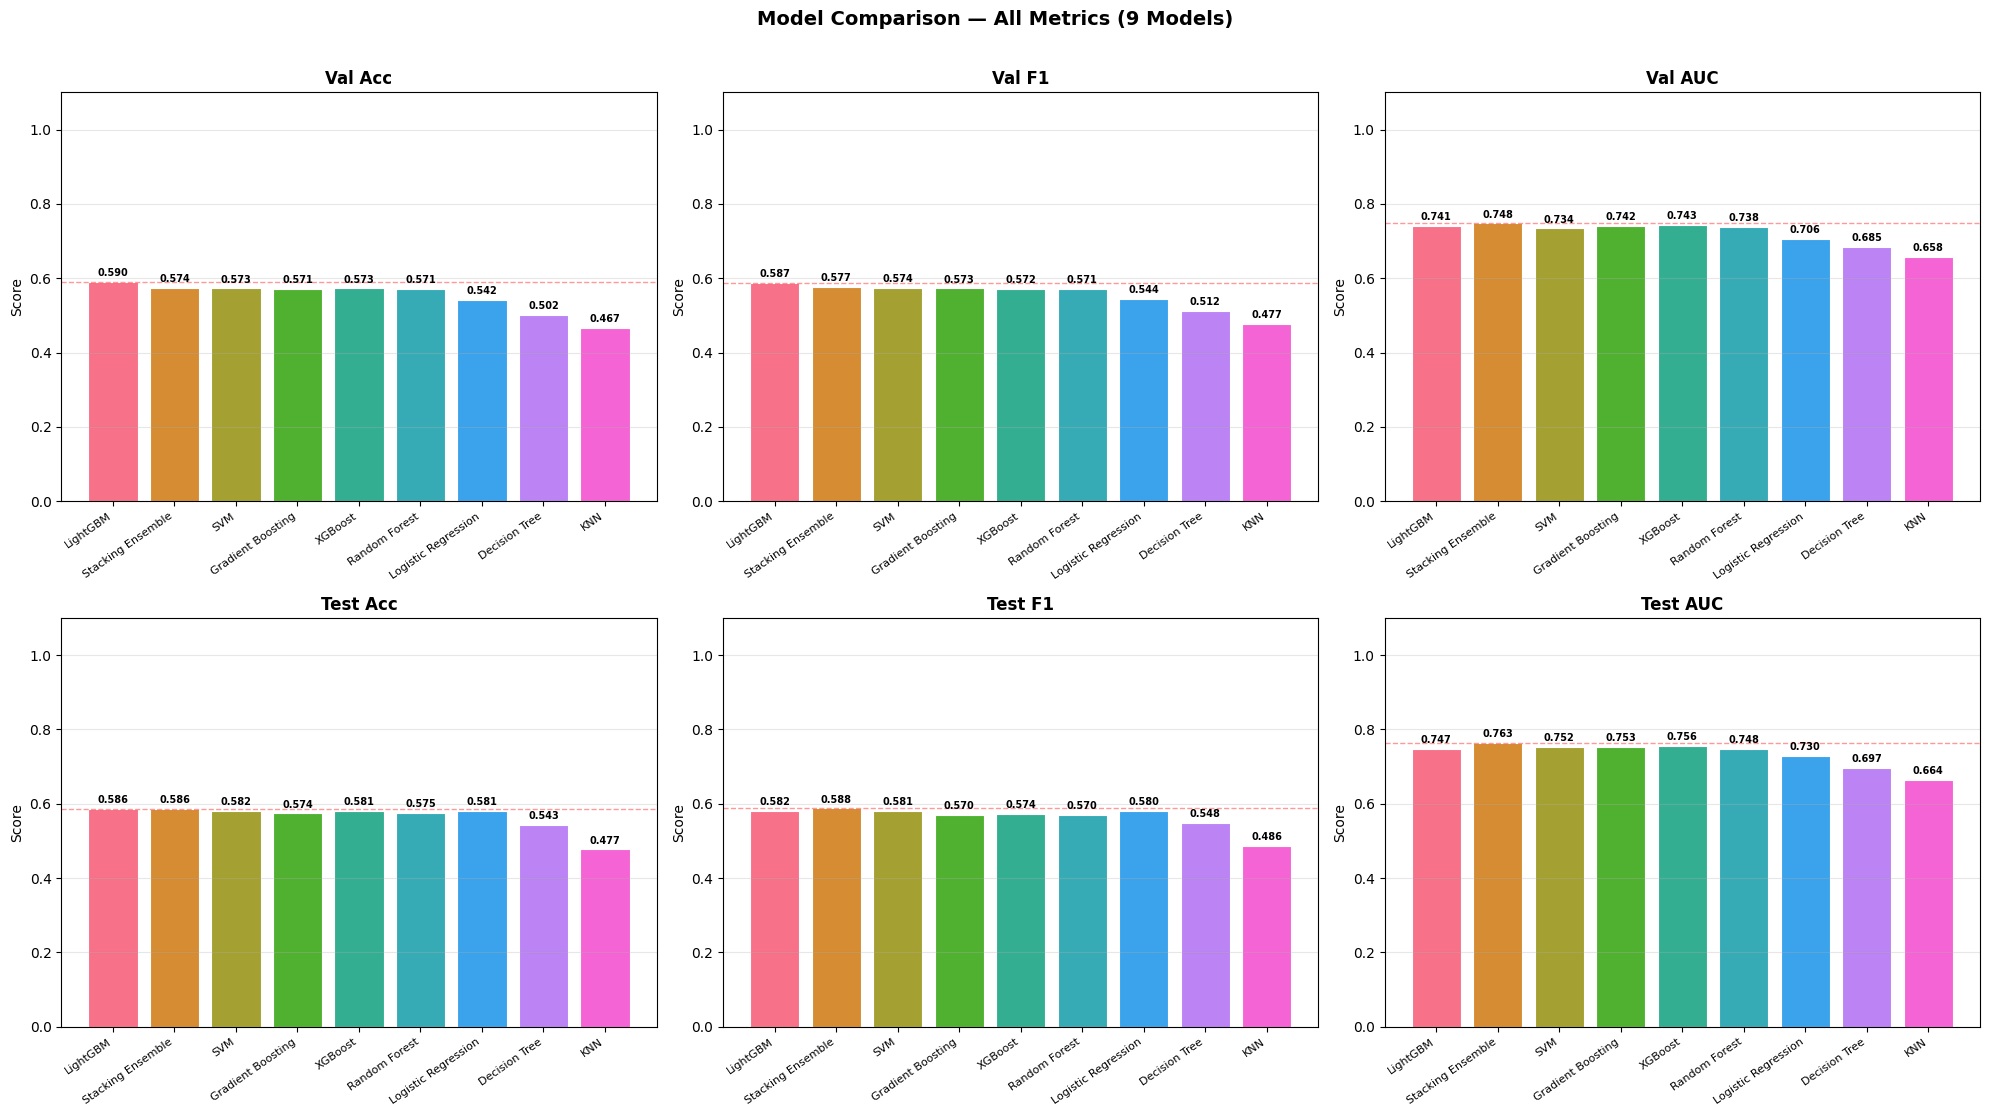

Saved: metric_comparison.png


In [66]:
metrics_to_plot = ["Val Acc", "Val F1", "Val AUC", "Test Acc", "Test F1", "Test AUC"]
fig, axes = plt.subplots(2, 3, figsize=(20, 11))
axes = axes.flatten()
palette = sns.color_palette("husl", len(results_df))

for i, metric in enumerate(metrics_to_plot):
    ax = axes[i]
    bars = ax.bar(results_df["Model"], results_df[metric],
                  color=palette, edgecolor='white', linewidth=0.8)
    ax.set_title(metric, fontsize=12, fontweight='bold')
    ax.set_ylim(0, 1.1)
    ax.set_ylabel("Score")
    ax.set_xticklabels(results_df["Model"], rotation=35, ha='right', fontsize=8)
    ax.axhline(y=results_df[metric].max(), color='red', linestyle='--', alpha=0.4, linewidth=1)
    ax.grid(axis='y', alpha=0.3)
    for bar, val in zip(bars, results_df[metric]):
        ax.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.01,
                f'{val:.3f}', ha='center', va='bottom', fontsize=7, fontweight='bold')

plt.suptitle("Model Comparison — All Metrics (9 Models)", fontsize=14, fontweight='bold', y=1.01)
plt.tight_layout()
plt.savefig("metric_comparison.png", dpi=150, bbox_inches='tight')
plt.show()
print("Saved: metric_comparison.png")

## STEP 17 — Overfitting Gap Visualization

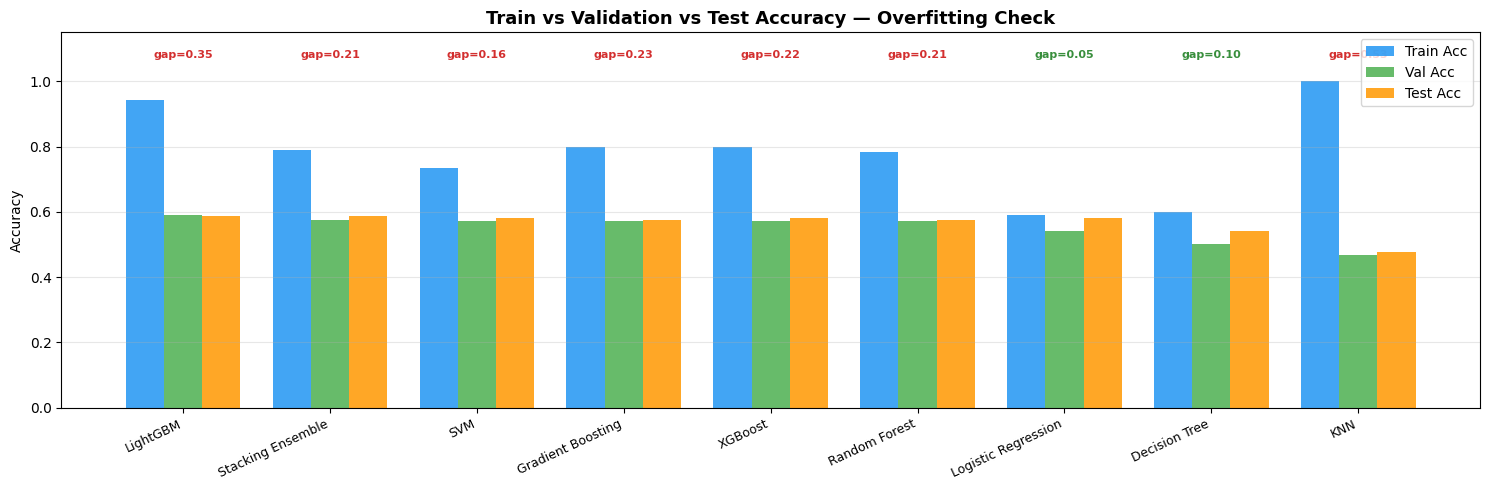

Saved: overfitting_gap.png


In [67]:
fig, ax = plt.subplots(figsize=(15, 5))
x = np.arange(len(results_df))
w = 0.26

ax.bar(x - w, results_df["Train Acc"], w, label="Train Acc", color='#2196F3', alpha=0.85)
ax.bar(x,     results_df["Val Acc"],   w, label="Val Acc",   color='#4CAF50', alpha=0.85)
ax.bar(x + w, results_df["Test Acc"],  w, label="Test Acc",  color='#FF9800', alpha=0.85)

ax.set_xticks(x)
ax.set_xticklabels(results_df["Model"], rotation=25, ha='right', fontsize=9)
ax.set_ylabel("Accuracy")
ax.set_ylim(0, 1.15)
ax.set_title("Train vs Validation vs Test Accuracy — Overfitting Check", fontsize=13, fontweight='bold')
ax.legend(fontsize=10)
ax.grid(axis='y', alpha=0.3)

for i, (_, row) in enumerate(results_df.iterrows()):
    gap = row["Overfit Gap"]
    color = '#d32f2f' if gap > 0.10 else '#388e3c'
    ax.text(i, 1.07, f"gap={gap:.2f}", ha='center', fontsize=8, color=color, fontweight='bold')

plt.tight_layout()
plt.savefig("overfitting_gap.png", dpi=150, bbox_inches='tight')
plt.show()
print("Saved: overfitting_gap.png")

## STEP 18 — Validation vs Model Complexity Curves (All 8 Base Models)

Computing complexity curves (takes a few minutes)...


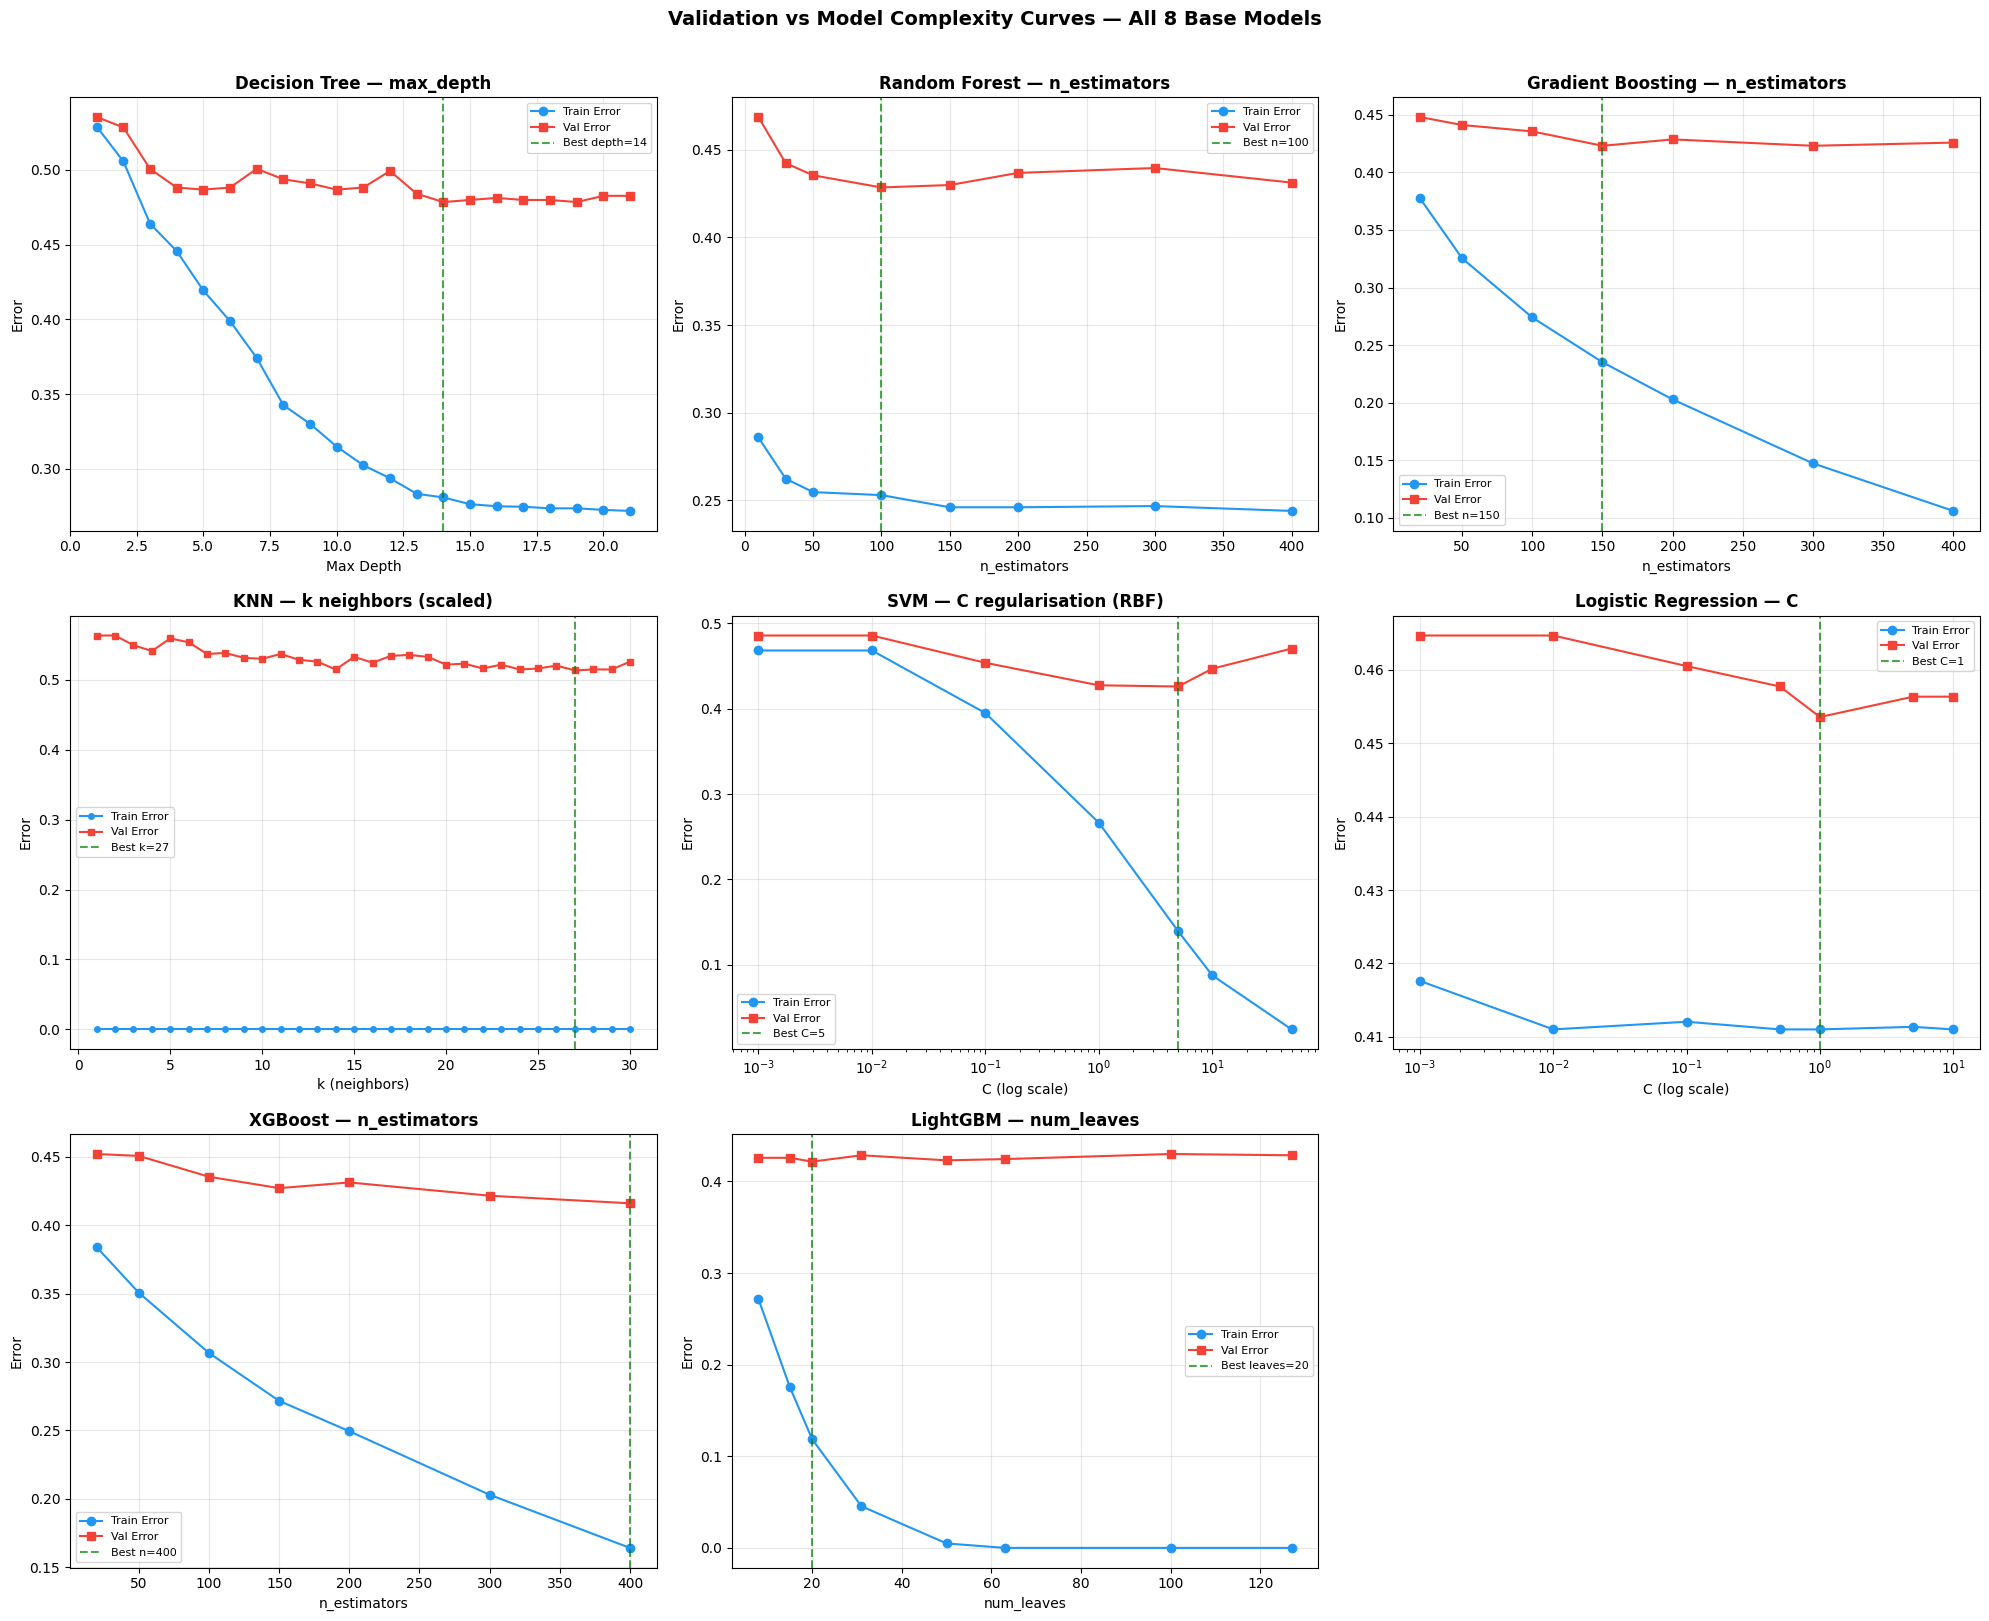

Saved: complexity_curves.png


In [68]:
print("Computing complexity curves (takes a few minutes)...")
fig, axes = plt.subplots(3, 3, figsize=(20, 16))
axes = axes.flatten()

# ── 1. Decision Tree — max_depth ─────────────────────────────────
ax = axes[0]
depths = range(1, 22)
tr_err, vl_err = [], []
for d in depths:
    p = make_pipeline(DecisionTreeClassifier(max_depth=d, min_samples_leaf=10,
                                              class_weight='balanced', random_state=42))
    p.fit(X_train, y_train)
    tr_err.append(1 - accuracy_score(y_train, p.predict(X_train)))
    vl_err.append(1 - accuracy_score(y_val,   p.predict(X_val)))
ax.plot(depths, tr_err, 'o-', color='#2196F3', label='Train Error')
ax.plot(depths, vl_err, 's-', color='#F44336', label='Val Error')
best_d = list(depths)[np.argmin(vl_err)]
ax.axvline(x=best_d, color='green', linestyle='--', alpha=0.7, label=f'Best depth={best_d}')
ax.set_xlabel("Max Depth"); ax.set_ylabel("Error")
ax.set_title("Decision Tree — max_depth", fontweight='bold')
ax.legend(fontsize=8); ax.grid(alpha=0.3)

# ── 2. Random Forest — n_estimators ──────────────────────────────
ax = axes[1]
n_trees = [10, 30, 50, 100, 150, 200, 300, 400]
tr_err, vl_err = [], []
for n in n_trees:
    p = make_pipeline(RandomForestClassifier(n_estimators=n, max_depth=10,
                                              min_samples_leaf=8, class_weight='balanced',
                                              random_state=42, n_jobs=-1))
    p.fit(X_train, y_train)
    tr_err.append(1 - accuracy_score(y_train, p.predict(X_train)))
    vl_err.append(1 - accuracy_score(y_val,   p.predict(X_val)))
ax.plot(n_trees, tr_err, 'o-', color='#2196F3', label='Train Error')
ax.plot(n_trees, vl_err, 's-', color='#F44336', label='Val Error')
ax.axvline(x=n_trees[np.argmin(vl_err)], color='green', linestyle='--', alpha=0.7,
           label=f"Best n={n_trees[np.argmin(vl_err)]}")
ax.set_xlabel("n_estimators"); ax.set_ylabel("Error")
ax.set_title("Random Forest — n_estimators", fontweight='bold')
ax.legend(fontsize=8); ax.grid(alpha=0.3)

# ── 3. Gradient Boosting — n_estimators ──────────────────────────
ax = axes[2]
n_est = [20, 50, 100, 150, 200, 300, 400]
tr_err, vl_err = [], []
for n in n_est:
    p = make_pipeline(GradientBoostingClassifier(n_estimators=n, max_depth=4,
                                                  learning_rate=0.05, min_samples_leaf=15,
                                                  subsample=0.8, random_state=42))
    p.fit(X_train, y_train)
    tr_err.append(1 - accuracy_score(y_train, p.predict(X_train)))
    vl_err.append(1 - accuracy_score(y_val,   p.predict(X_val)))
ax.plot(n_est, tr_err, 'o-', color='#2196F3', label='Train Error')
ax.plot(n_est, vl_err, 's-', color='#F44336', label='Val Error')
ax.axvline(x=n_est[np.argmin(vl_err)], color='green', linestyle='--', alpha=0.7,
           label=f"Best n={n_est[np.argmin(vl_err)]}")
ax.set_xlabel("n_estimators"); ax.set_ylabel("Error")
ax.set_title("Gradient Boosting — n_estimators", fontweight='bold')
ax.legend(fontsize=8); ax.grid(alpha=0.3)

# ── 4. KNN — k neighbors ─────────────────────────────────────────
ax = axes[3]
ks = range(1, 31)
tr_err, vl_err = [], []
for k in ks:
    p = make_pipeline(KNeighborsClassifier(n_neighbors=k, weights='distance'))
    p.fit(X_train, y_train)
    tr_err.append(1 - accuracy_score(y_train, p.predict(X_train)))
    vl_err.append(1 - accuracy_score(y_val,   p.predict(X_val)))
ax.plot(list(ks), tr_err, 'o-', color='#2196F3', label='Train Error', markersize=4)
ax.plot(list(ks), vl_err, 's-', color='#F44336', label='Val Error',   markersize=4)
ax.axvline(x=list(ks)[np.argmin(vl_err)], color='green', linestyle='--', alpha=0.7,
           label=f"Best k={list(ks)[np.argmin(vl_err)]}")
ax.set_xlabel("k (neighbors)"); ax.set_ylabel("Error")
ax.set_title("KNN — k neighbors (scaled)", fontweight='bold')
ax.legend(fontsize=8); ax.grid(alpha=0.3)

# ── 5. SVM — C regularisation ─────────────────────────────────────
ax = axes[4]
C_vals = [0.001, 0.01, 0.1, 1, 5, 10, 50]
tr_err, vl_err = [], []
for c in C_vals:
    p = make_pipeline(SVC(C=c, kernel='rbf', class_weight='balanced',
                          probability=True, random_state=42))
    p.fit(X_train, y_train)
    tr_err.append(1 - accuracy_score(y_train, p.predict(X_train)))
    vl_err.append(1 - accuracy_score(y_val,   p.predict(X_val)))
ax.semilogx(C_vals, tr_err, 'o-', color='#2196F3', label='Train Error')
ax.semilogx(C_vals, vl_err, 's-', color='#F44336', label='Val Error')
ax.axvline(x=C_vals[np.argmin(vl_err)], color='green', linestyle='--', alpha=0.7,
           label=f"Best C={C_vals[np.argmin(vl_err)]}")
ax.set_xlabel("C (log scale)"); ax.set_ylabel("Error")
ax.set_title("SVM — C regularisation (RBF)", fontweight='bold')
ax.legend(fontsize=8); ax.grid(alpha=0.3)

# ── 6. Logistic Regression — C ────────────────────────────────────
ax = axes[5]
C_vals_lr = [0.001, 0.01, 0.1, 0.5, 1, 5, 10]
tr_err, vl_err = [], []
for c in C_vals_lr:
    p = make_pipeline(LogisticRegression(C=c, max_iter=2000,
                                          class_weight='balanced', random_state=42))
    p.fit(X_train, y_train)
    tr_err.append(1 - accuracy_score(y_train, p.predict(X_train)))
    vl_err.append(1 - accuracy_score(y_val,   p.predict(X_val)))
ax.semilogx(C_vals_lr, tr_err, 'o-', color='#2196F3', label='Train Error')
ax.semilogx(C_vals_lr, vl_err, 's-', color='#F44336', label='Val Error')
ax.axvline(x=C_vals_lr[np.argmin(vl_err)], color='green', linestyle='--', alpha=0.7,
           label=f"Best C={C_vals_lr[np.argmin(vl_err)]}")
ax.set_xlabel("C (log scale)"); ax.set_ylabel("Error")
ax.set_title("Logistic Regression — C", fontweight='bold')
ax.legend(fontsize=8); ax.grid(alpha=0.3)

# ── 7. XGBoost — n_estimators ─────────────────────────────────────
ax = axes[6]
n_xgb = [20, 50, 100, 150, 200, 300, 400]
tr_err, vl_err = [], []
for n in n_xgb:
    p = make_pipeline(xgb.XGBClassifier(n_estimators=n, max_depth=4,
                                         learning_rate=0.05, subsample=0.8,
                                         colsample_bytree=0.8, reg_lambda=1.0,
                                         min_child_weight=5,
                                         use_label_encoder=False,
                                         eval_metric='mlogloss',
                                         random_state=42, n_jobs=-1))
    p.fit(X_train, y_train)
    tr_err.append(1 - accuracy_score(y_train, p.predict(X_train)))
    vl_err.append(1 - accuracy_score(y_val,   p.predict(X_val)))
ax.plot(n_xgb, tr_err, 'o-', color='#2196F3', label='Train Error')
ax.plot(n_xgb, vl_err, 's-', color='#F44336', label='Val Error')
ax.axvline(x=n_xgb[np.argmin(vl_err)], color='green', linestyle='--', alpha=0.7,
           label=f"Best n={n_xgb[np.argmin(vl_err)]}")
ax.set_xlabel("n_estimators"); ax.set_ylabel("Error")
ax.set_title("XGBoost — n_estimators", fontweight='bold')
ax.legend(fontsize=8); ax.grid(alpha=0.3)

# ── 8. LightGBM — num_leaves ──────────────────────────────────────
ax = axes[7]
n_leaves = [8, 15, 20, 31, 50, 63, 100, 127]
tr_err, vl_err = [], []
for nl in n_leaves:
    p = make_pipeline(lgb.LGBMClassifier(n_estimators=200, num_leaves=nl,
                                          learning_rate=0.05, subsample=0.8,
                                          colsample_bytree=0.8, reg_lambda=1.0,
                                          min_child_samples=20,
                                          class_weight='balanced',
                                          random_state=42, n_jobs=-1, verbose=-1))
    p.fit(X_train, y_train)
    tr_err.append(1 - accuracy_score(y_train, p.predict(X_train)))
    vl_err.append(1 - accuracy_score(y_val,   p.predict(X_val)))
ax.plot(n_leaves, tr_err, 'o-', color='#2196F3', label='Train Error')
ax.plot(n_leaves, vl_err, 's-', color='#F44336', label='Val Error')
ax.axvline(x=n_leaves[np.argmin(vl_err)], color='green', linestyle='--', alpha=0.7,
           label=f"Best leaves={n_leaves[np.argmin(vl_err)]}")
ax.set_xlabel("num_leaves"); ax.set_ylabel("Error")
ax.set_title("LightGBM — num_leaves", fontweight='bold')
ax.legend(fontsize=8); ax.grid(alpha=0.3)

axes[8].set_visible(False)  # 9th slot — hide

plt.suptitle("Validation vs Model Complexity Curves — All 8 Base Models",
             fontsize=14, fontweight='bold', y=1.01)
plt.tight_layout()
plt.savefig("complexity_curves.png", dpi=150, bbox_inches='tight')
plt.show()
print("Saved: complexity_curves.png")

## STEP 19 — Feature Importance (Random Forest, XGBoost, LightGBM)

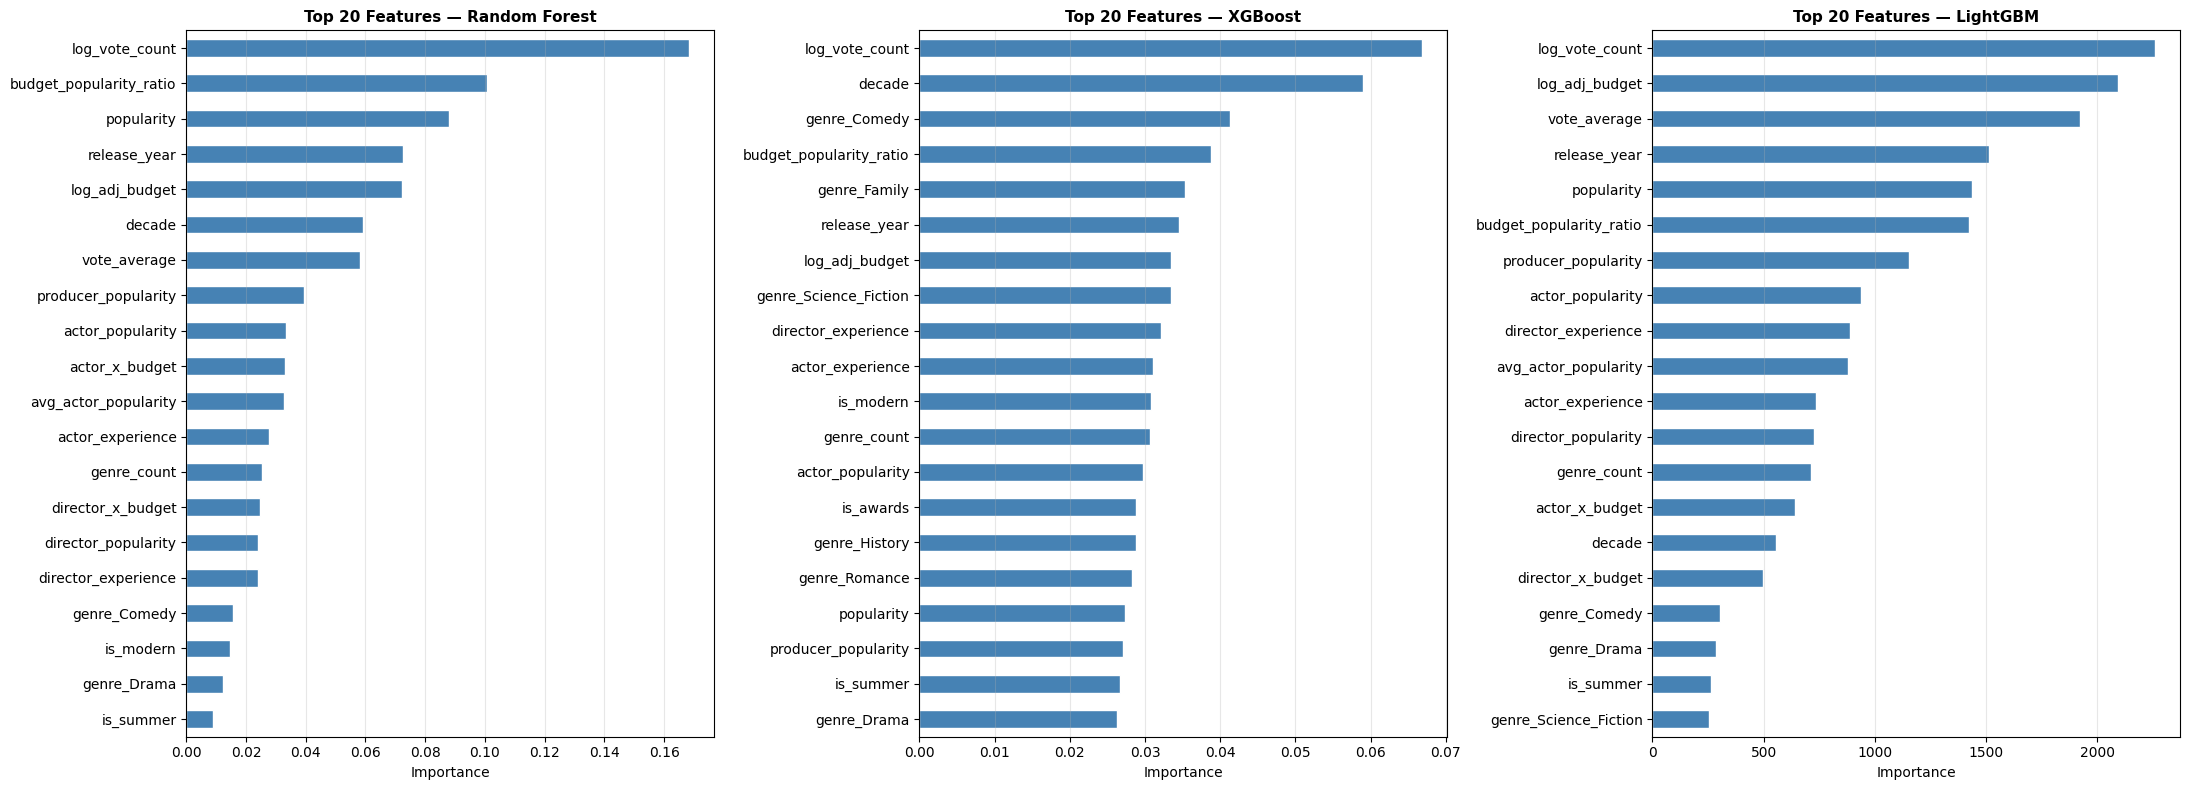

Saved: feature_importance.png


In [69]:
fig, axes = plt.subplots(1, 3, figsize=(22, 8))

importance_models = {
    "Random Forest":  'feature_importances_',
    "XGBoost":        'feature_importances_',
    "LightGBM":       'feature_importances_',
}

for ax, (mname, attr) in zip(axes, importance_models.items()):
    pipe = trained_pipelines[mname]
    clf  = pipe.named_steps['clf']
    imps = getattr(clf, attr)
    feat_imp = pd.Series(imps, index=X.columns).sort_values(ascending=False).head(20)
    feat_imp.sort_values().plot(kind='barh', ax=ax, color='steelblue', edgecolor='white')
    ax.set_title(f"Top 20 Features — {mname}", fontsize=11, fontweight='bold')
    ax.set_xlabel("Importance")
    ax.grid(axis='x', alpha=0.3)

plt.tight_layout()
plt.savefig("feature_importance.png", dpi=150, bbox_inches='tight')
plt.show()
print("Saved: feature_importance.png")

## STEP 20 — Cross-Validation F1 Score Comparison

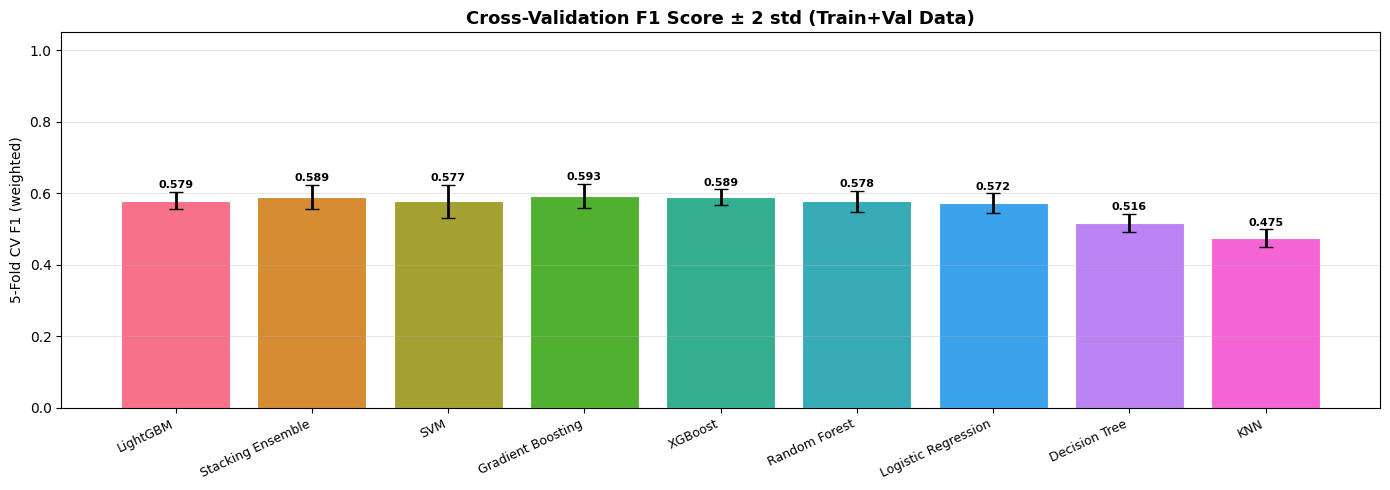

Saved: cv_scores.png


In [70]:
fig, ax = plt.subplots(figsize=(14, 5))
x = np.arange(len(results_df))
bars = ax.bar(x, results_df["CV F1 Mean"],
              yerr=results_df["CV F1 Std"] * 2,
              capsize=5, color=sns.color_palette("husl", len(results_df)),
              edgecolor='white', linewidth=0.8,
              error_kw={'linewidth': 2})

ax.set_xticks(x)
ax.set_xticklabels(results_df["Model"], rotation=25, ha='right', fontsize=9)
ax.set_ylabel("5-Fold CV F1 (weighted)")
ax.set_ylim(0, 1.05)
ax.set_title("Cross-Validation F1 Score ± 2 std (Train+Val Data)", fontsize=13, fontweight='bold')
ax.grid(axis='y', alpha=0.3)

for bar, val, std in zip(bars, results_df["CV F1 Mean"], results_df["CV F1 Std"]):
    ax.text(bar.get_x() + bar.get_width()/2, bar.get_height() + std * 2 + 0.01,
            f'{val:.3f}', ha='center', fontsize=8, fontweight='bold')

plt.tight_layout()
plt.savefig("cv_scores.png", dpi=150, bbox_inches='tight')
plt.show()
print("Saved: cv_scores.png")

## STEP 21 — Radar Chart: Model Profile (Val F1, AUC, CV F1, 1-OverfitGap)

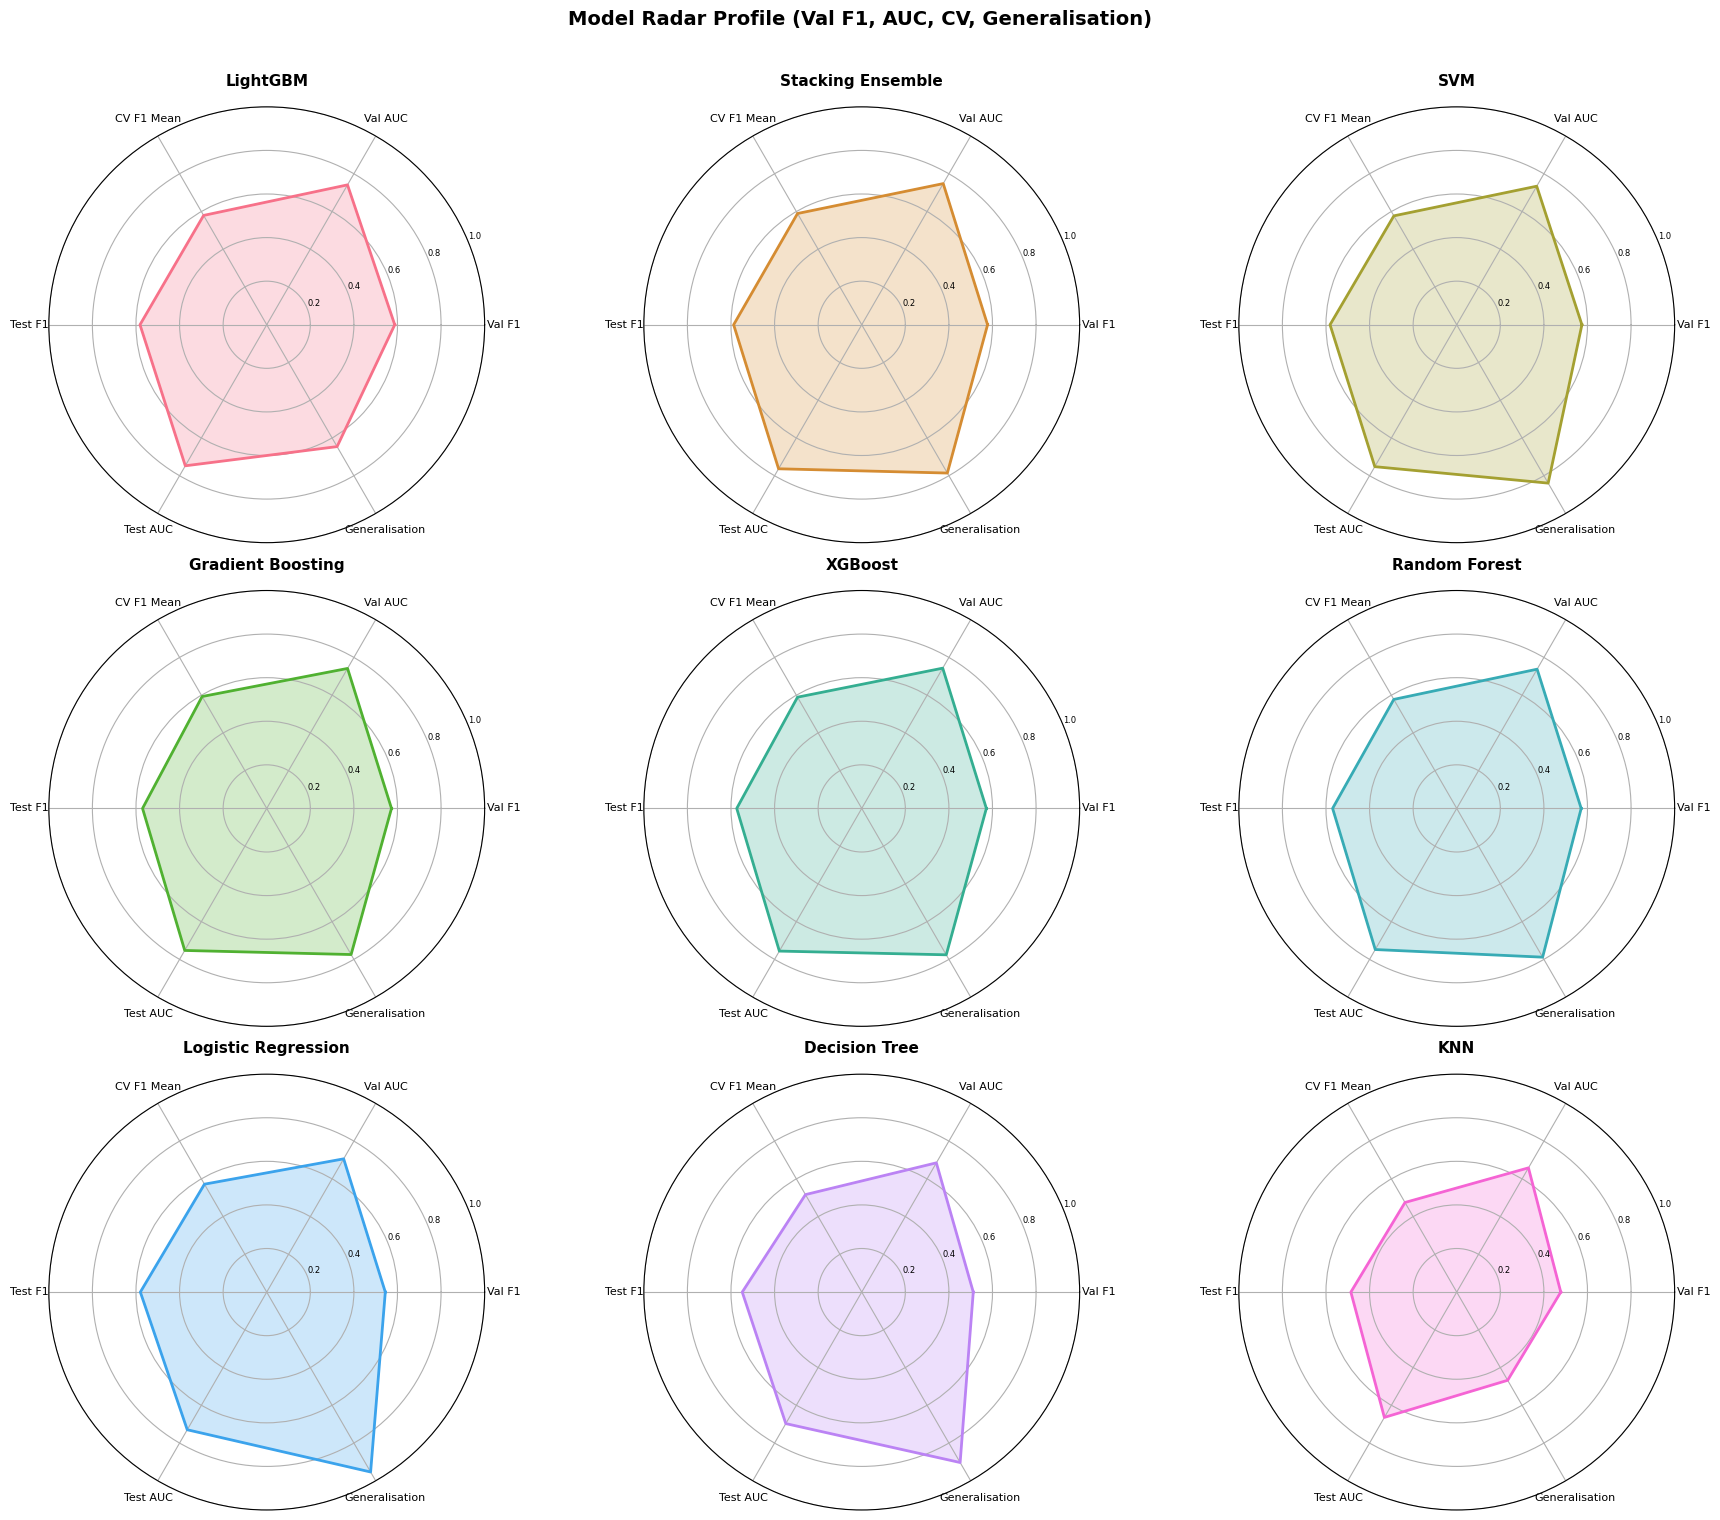

Saved: radar_profiles.png


In [71]:
radar_metrics = ["Val F1", "Val AUC", "CV F1 Mean", "Test F1", "Test AUC"]
# Add generalisation score = 1 - Overfit Gap (clipped at 0)
results_df["Generalisation"] = (1 - results_df["Overfit Gap"]).clip(0, 1)
radar_metrics += ["Generalisation"]

N = len(radar_metrics)
angles = np.linspace(0, 2 * np.pi, N, endpoint=False).tolist()
angles += angles[:1]  # close circle

fig, axes = plt.subplots(3, 3, figsize=(18, 15), subplot_kw=dict(polar=True))
axes = axes.flatten()
colors = sns.color_palette("husl", len(results_df))

for i, (_, row) in enumerate(results_df.iterrows()):
    ax = axes[i]
    vals = [row[m] for m in radar_metrics]
    vals += vals[:1]
    ax.plot(angles, vals, color=colors[i], lw=2)
    ax.fill(angles, vals, color=colors[i], alpha=0.25)
    ax.set_xticks(angles[:-1])
    ax.set_xticklabels(radar_metrics, fontsize=8)
    ax.set_ylim(0, 1)
    ax.set_title(row["Model"], fontsize=11, fontweight='bold', pad=15)
    ax.yaxis.set_tick_params(labelsize=6)

for j in range(i + 1, len(axes)):
    axes[j].set_visible(False)

plt.suptitle("Model Radar Profile (Val F1, AUC, CV, Generalisation)",
             fontsize=14, fontweight='bold', y=1.01)
plt.tight_layout()
plt.savefig("radar_profiles.png", dpi=150, bbox_inches='tight')
plt.show()
print("Saved: radar_profiles.png")

## STEP 22 — Best Model Selection & Final Evaluation

Best model selected by **Test F1** (most reliable — completely unseen data).  
Retrained on full train+val set before reporting final results.

In [72]:
best_row  = results_df.sort_values("Test F1", ascending=False).iloc[0]
best_name = best_row["Model"]
print(f"🏆 Best Model: {best_name}")
print(f"   Val  F1     = {best_row['Val F1']:.4f}")
print(f"   Test F1     = {best_row['Test F1']:.4f}")
print(f"   Test AUC    = {best_row['Test AUC']:.4f}")
print(f"   CV F1 Mean  = {best_row['CV F1 Mean']:.4f} ± {best_row['CV F1 Std']:.4f}")
print(f"   Overfit Gap = {best_row['Overfit Gap']:.4f}")

🏆 Best Model: Stacking Ensemble
   Val  F1     = 0.5774
   Test F1     = 0.5878
   Test AUC    = 0.7632
   CV F1 Mean  = 0.5894 ± 0.0171
   Overfit Gap = 0.2142


In [73]:
# Retrain best model on full train+val data (standard practice before deployment)
if best_name == "Stacking Ensemble":
    best_final = stack_clf.__class__(
        estimators=stack_clf.estimators,
        final_estimator=stack_clf.final_estimator,
        cv=StratifiedKFold(n_splits=5, shuffle=True, random_state=42),
        stack_method='predict_proba',
        n_jobs=-1
    )
else:
    base_clf = model_defs[best_name]
    best_final = make_pipeline(base_clf.__class__(**base_clf.get_params()))

best_final.fit(X_trainval, y_trainval)

y_final_pred  = best_final.predict(X_test)
y_final_proba = best_final.predict_proba(X_test)

y_test_bin = label_binarize(y_test, classes=range(len(CLASSES)))

print(f"\n{'='*60}")
print(f"  FINAL EVALUATION — {best_name} (retrained on train+val)")
print(f"{'='*60}")
print(f"  Test Accuracy : {accuracy_score(y_test, y_final_pred):.4f}")
print(f"  Test F1       : {f1_score(y_test, y_final_pred, average='weighted'):.4f}")
print(f"  Test AUC      : {roc_auc_score(y_test_bin, y_final_proba, multi_class='ovr', average='macro'):.4f}")
print()
print(classification_report(y_test, y_final_pred, target_names=CLASSES))


  FINAL EVALUATION — Stacking Ensemble (retrained on train+val)
  Test Accuracy : 0.5860
  Test F1       : 0.5876
  Test AUC      : 0.7663

              precision    recall  f1-score   support

         Avg       0.41      0.40      0.41       251
        Flop       0.55      0.65      0.60       243
         Hit       0.73      0.66      0.69       407

    accuracy                           0.59       901
   macro avg       0.56      0.57      0.57       901
weighted avg       0.59      0.59      0.59       901



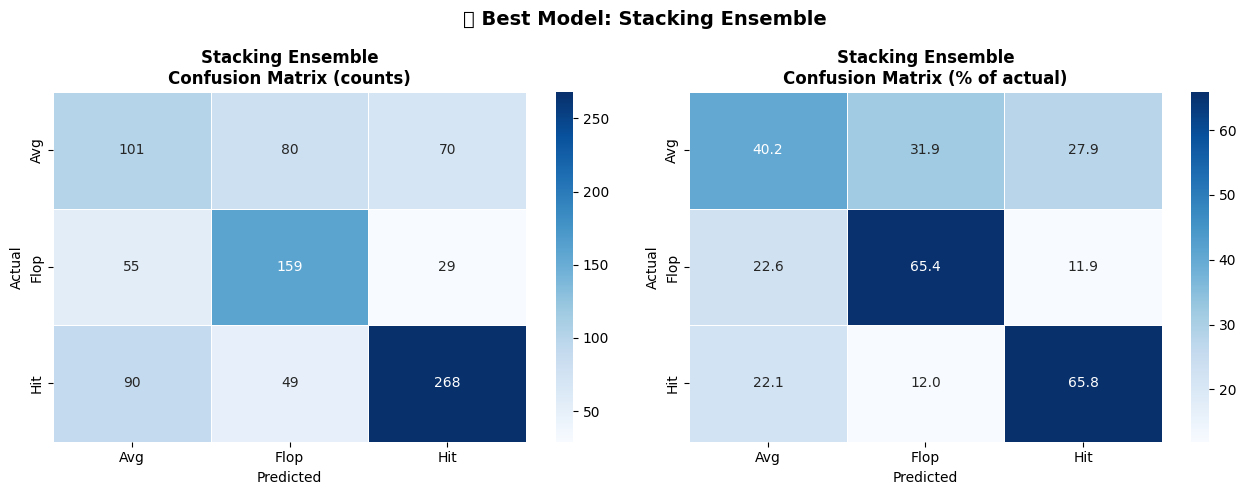


✅ All done! Best model = Stacking Ensemble
Saved figures:
  label_distribution.png, confusion_matrices.png, roc_curves.png,
  metric_comparison.png, overfitting_gap.png, complexity_curves.png,
  feature_importance.png, cv_scores.png, radar_profiles.png, best_model_cm.png


In [74]:
# Final confusion matrix — counts + percentages side by side
fig, axes = plt.subplots(1, 2, figsize=(13, 5))

cm = confusion_matrix(y_test, y_final_pred)
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
            xticklabels=CLASSES, yticklabels=CLASSES,
            ax=axes[0], linewidths=0.5)
axes[0].set_title(f"{best_name}\nConfusion Matrix (counts)", fontweight='bold')
axes[0].set_xlabel("Predicted"); axes[0].set_ylabel("Actual")

cm_pct = cm.astype(float) / cm.sum(axis=1, keepdims=True) * 100
sns.heatmap(cm_pct, annot=True, fmt='.1f', cmap='Blues',
            xticklabels=CLASSES, yticklabels=CLASSES,
            ax=axes[1], linewidths=0.5)
axes[1].set_title(f"{best_name}\nConfusion Matrix (% of actual)", fontweight='bold')
axes[1].set_xlabel("Predicted"); axes[1].set_ylabel("Actual")

plt.suptitle(f"🏆 Best Model: {best_name}", fontsize=14, fontweight='bold')
plt.tight_layout()
plt.savefig("best_model_cm.png", dpi=150, bbox_inches='tight')
plt.show()

print(f"\n✅ All done! Best model = {best_name}")
print("Saved figures:")
print("  label_distribution.png, confusion_matrices.png, roc_curves.png,")
print("  metric_comparison.png, overfitting_gap.png, complexity_curves.png,")
print("  feature_importance.png, cv_scores.png, radar_profiles.png, best_model_cm.png")

In [75]:
# ── Save final preprocessed dataset ─────────────────────────────

# Combine features and target
final_df = X.copy()
final_df['target'] = y.values

# Save to CSV
output_path = "final_preprocessed_movies_dataset.csv"
final_df.to_csv(output_path, index=False)

print(f"✅ Final dataset saved at: {output_path}")
print(f"Shape: {final_df.shape}")

✅ Final dataset saved at: final_preprocessed_movies_dataset.csv
Shape: (4505, 36)
